# TCC Parte 1 - Carregando e Tratando os Dados

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import pearsonr

import numpy as np

from modules.chart_helpers import print_line_series
from modules.dataframe_helpers import count_largest_missing_interval, compute_returns_for_prices, compute_lags, compute_targets
from modules.statistical_tests import shapiro_wilk_gaussian_test, adf_test

In [2]:
abev3 = pd.read_csv("./stocks/ABEV3.csv")
bbdc3 = pd.read_csv("./stocks/BBDC3.csv")
itsa3 = pd.read_csv("./stocks/ITSA3.csv")
itub3 = pd.read_csv("./stocks/ITUB3.csv")
wege3 = pd.read_csv("./stocks/WEGE3.csv")

In [3]:
abev3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,13.28,13.26,13.45,13.17,36.59M,-0.90%
1,10/03/2024,13.40,13.55,13.63,13.40,44.99M,-2.33%
2,10/02/2024,13.72,13.70,13.85,13.61,51.03M,0.88%
3,10/01/2024,13.60,13.20,13.72,13.13,65.79M,3.98%
4,09/30/2024,13.08,12.94,13.17,12.90,31.05M,1.24%


In [4]:
bbdc3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,13.29,13.19,13.42,13.10,5.32M,0.30%
1,10/03/2024,13.25,13.28,13.42,13.14,5.28M,-0.97%
2,10/02/2024,13.38,13.30,13.54,13.27,8.59M,3.22%
3,10/01/2024,12.96,13.04,13.11,12.84,7.16M,0.54%
4,09/30/2024,12.89,13.05,13.08,12.87,5.90M,-1.13%


In [5]:
itsa3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,10.63,10.57,10.68,10.55,114.10K,0.76%
1,10/03/2024,10.55,10.91,10.91,10.55,294.10K,-3.21%
2,10/02/2024,10.90,10.90,11.05,10.90,162.60K,0.46%
3,10/01/2024,10.85,11.07,11.07,10.79,432.30K,-2.08%
4,09/30/2024,11.08,11.12,11.16,11.00,122.70K,-0.63%


In [6]:
itub3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,30.46,30.39,30.60,30.27,310.50K,0.20%
1,10/03/2024,30.40,31.01,31.02,30.30,386.90K,-2.22%
2,10/02/2024,31.09,30.90,31.43,30.90,343.80K,0.65%
3,10/01/2024,30.89,31.41,31.49,30.77,467.50K,-1.66%
4,09/30/2024,31.41,31.86,32.01,31.41,428.40K,-1.50%


In [7]:
wege3.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/04/2024,54.50,54.36,54.98,54.26,4.82M,-0.18%
1,10/03/2024,54.60,54.76,55.00,53.95,4.47M,-1.36%
2,10/02/2024,55.35,56.13,56.37,55.14,5.12M,-0.95%
3,10/01/2024,55.88,55.00,56.22,54.80,8.03M,2.74%
4,09/30/2024,54.39,55.63,56.24,54.39,6.41M,-2.81%


Truncando os dados em um período de 17 anos pois os dados pré-2007 apresentavam inconsistências em uma inspeção visual

In [8]:
START_DATE = "2018-10-04"
END_DATE = "2024-10-04"

Transformando a data em Datetime para que os plots sejam feitos corretamente sobre o eixo temporal, caso contrário as datas em string são interpretadas como variáveis categóricas

In [9]:
abev3 = abev3.filter(["Date", "Price"], axis=1)
bbdc3 = bbdc3.filter(["Date", "Price"], axis=1)
itsa3 = itsa3.filter(["Date", "Price"], axis=1)
itub3 = itub3.filter(["Date", "Price"], axis=1)
wege3 = wege3.filter(["Date", "Price"], axis=1)

abev3['Date'] = pd.to_datetime(abev3['Date'], format='%m/%d/%Y')
bbdc3['Date'] = pd.to_datetime(bbdc3['Date'], format='%m/%d/%Y')
itsa3['Date'] = pd.to_datetime(itsa3['Date'], format='%m/%d/%Y')
itub3['Date'] = pd.to_datetime(itub3['Date'], format='%m/%d/%Y')
wege3['Date'] = pd.to_datetime(wege3['Date'], format='%m/%d/%Y')

In [10]:
abev3 = abev3[(abev3["Date"] >= START_DATE) & (abev3["Date"] <= END_DATE)]
abev3.tail()

,Date,Price
1491,2018-10-10,13.83
1492,2018-10-09,14.06
1493,2018-10-08,14.48
1494,2018-10-05,14.20
1495,2018-10-04,14.37


In [11]:
bbdc3 = bbdc3[(bbdc3["Date"] >= START_DATE) & (bbdc3["Date"] <= END_DATE)]
bbdc3.tail()

,Date,Price
1492,2018-10-10,14.91
1493,2018-10-09,15.58
1494,2018-10-08,15.56
1495,2018-10-05,14.78
1496,2018-10-04,15.22


In [12]:
itsa3 = itsa3[(itsa3["Date"] >= START_DATE) & (itsa3["Date"] <= END_DATE)]
itsa3.tail()

,Date,Price
1492,2018-10-10,6.87
1493,2018-10-09,6.99
1494,2018-10-08,6.96
1495,2018-10-05,6.80
1496,2018-10-04,6.80


In [13]:
itub3 = itub3[(itub3["Date"] >= START_DATE) & (itub3["Date"] <= END_DATE)]
itub3.tail()

,Date,Price
1492,2018-10-10,23.79
1493,2018-10-09,24.54
1494,2018-10-08,24.78
1495,2018-10-05,23.44
1496,2018-10-04,23.19


In [14]:
wege3 = wege3[(wege3["Date"] >= START_DATE) & (wege3["Date"] <= END_DATE)]
wege3.tail()

,Date,Price
1491,2018-10-10,8.87
1492,2018-10-09,8.82
1493,2018-10-08,9.18
1494,2018-10-05,9.21
1495,2018-10-04,9.21


In [15]:
abev3.set_index('Date', inplace=True)
bbdc3.set_index('Date', inplace=True)
itsa3.set_index('Date', inplace=True)
itub3.set_index('Date', inplace=True)
wege3.set_index('Date', inplace=True)

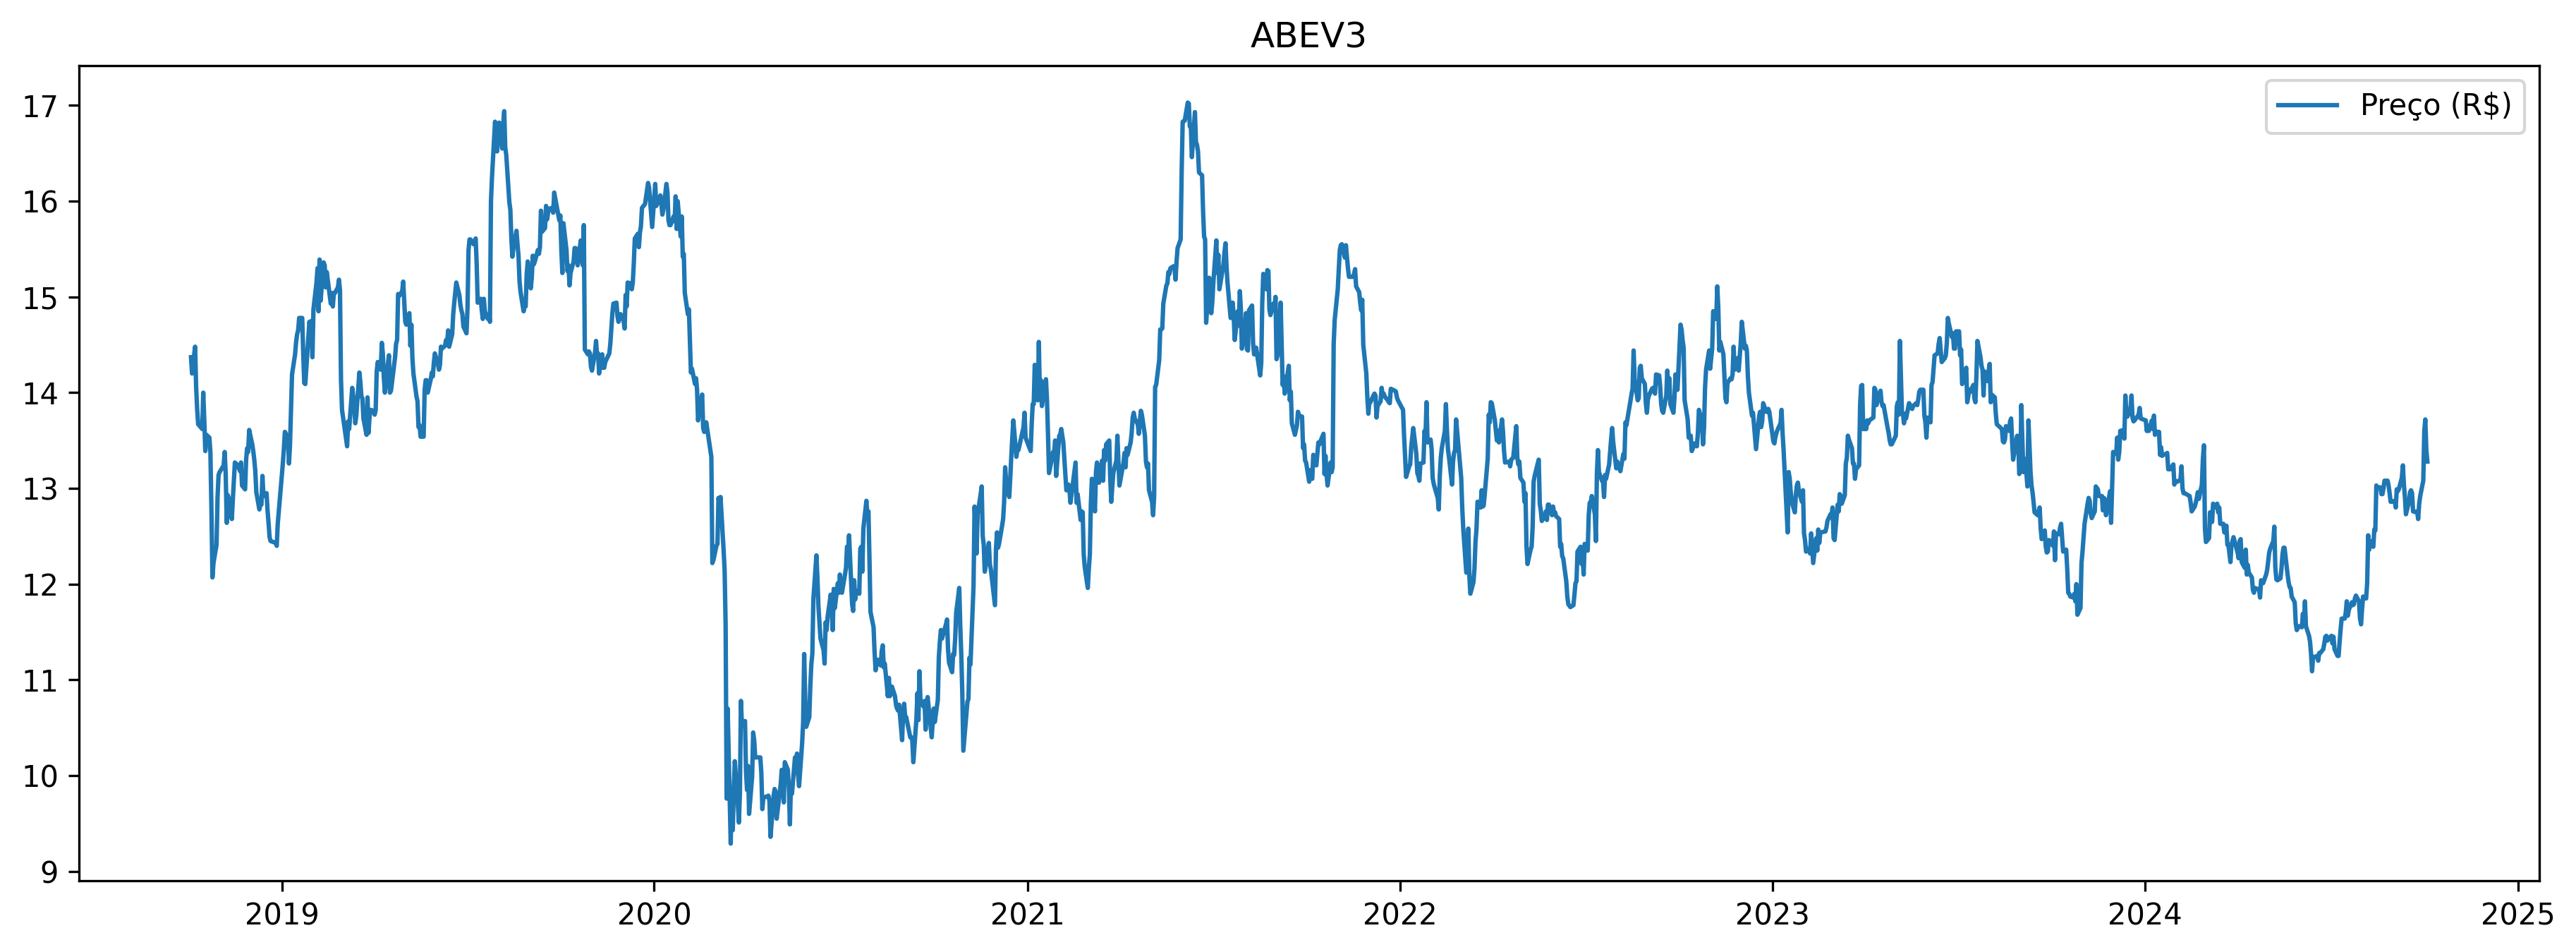

In [16]:
print_line_series(abev3, "ABEV3")

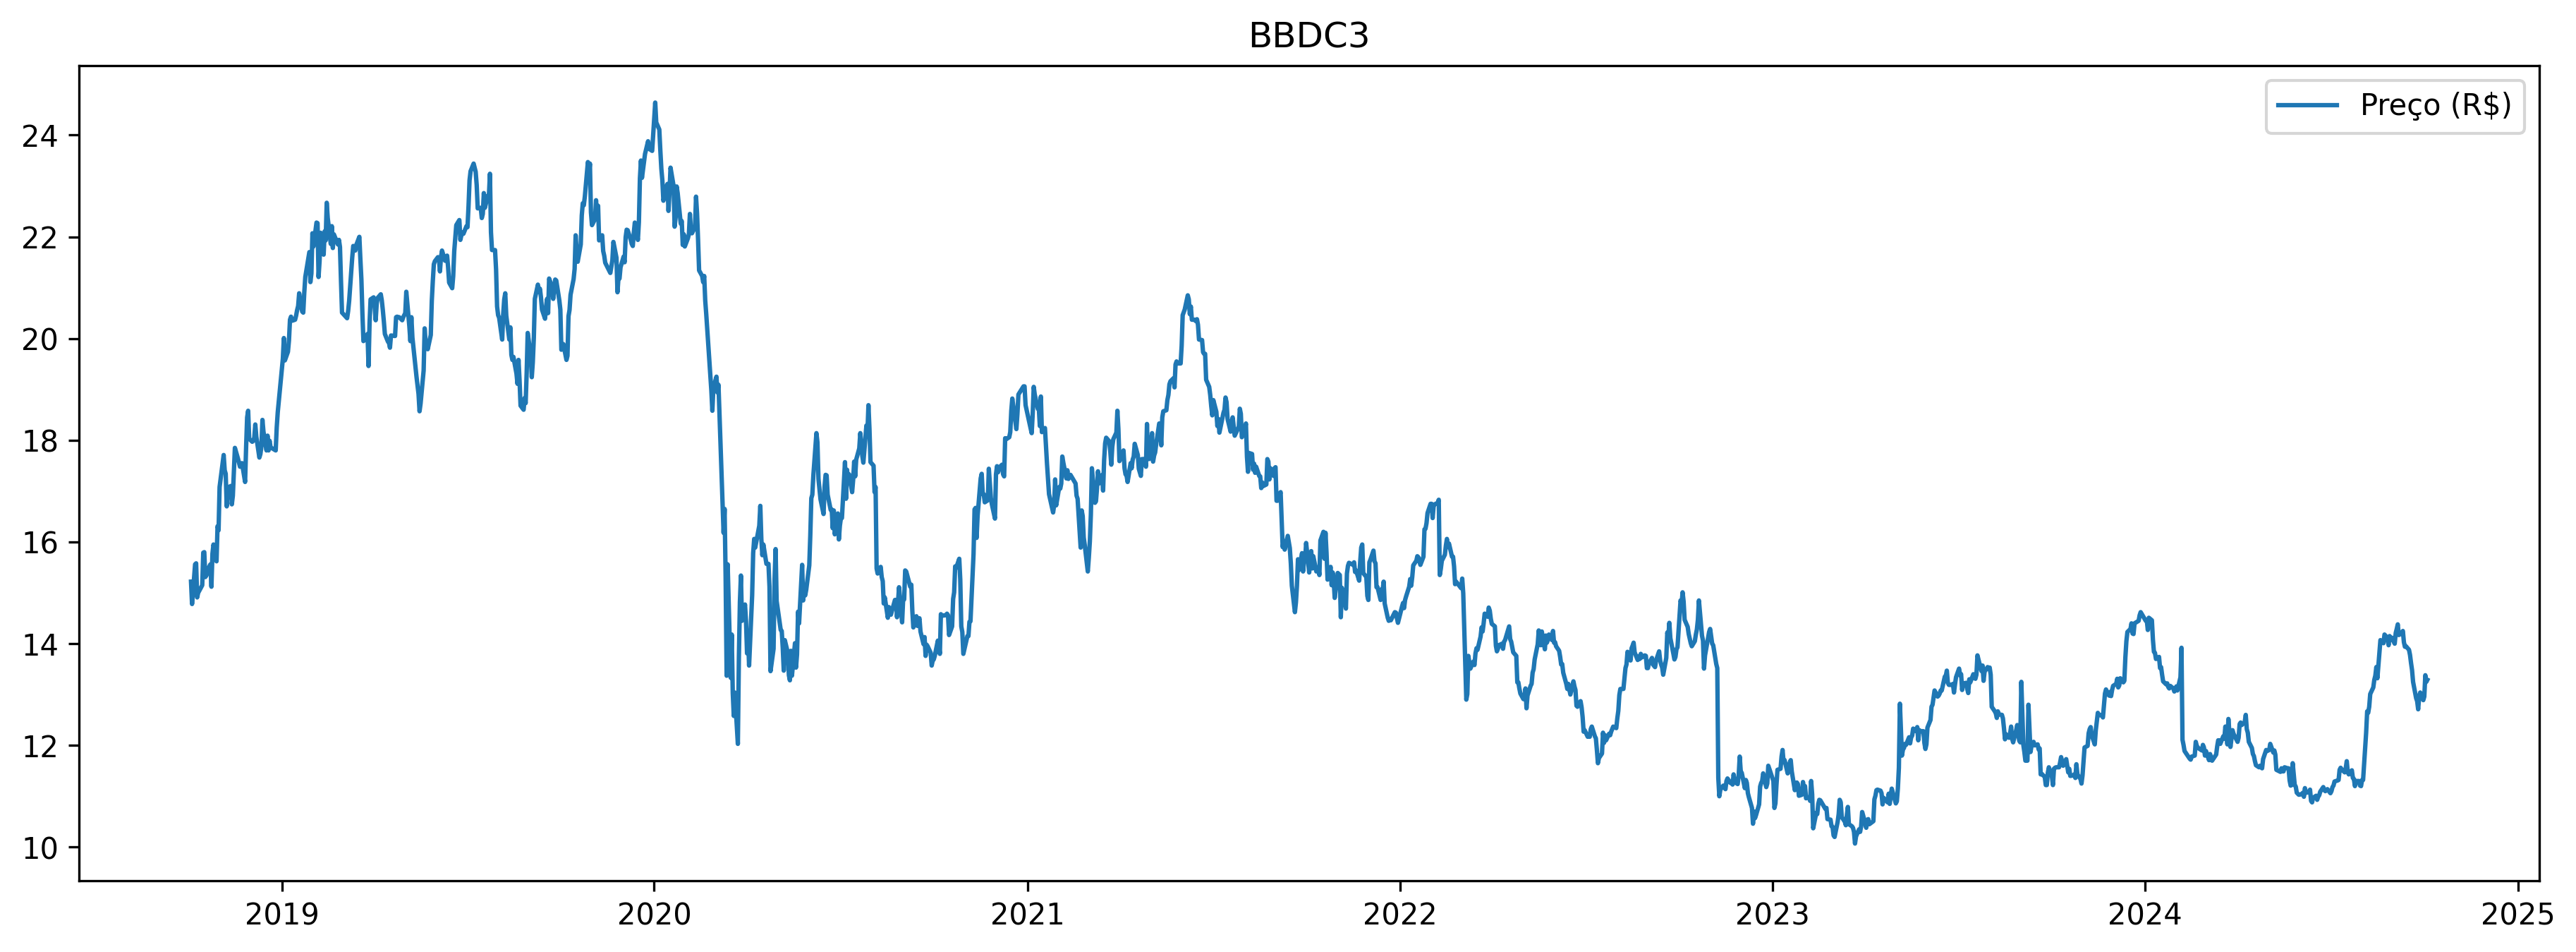

In [17]:
print_line_series(bbdc3, "BBDC3")

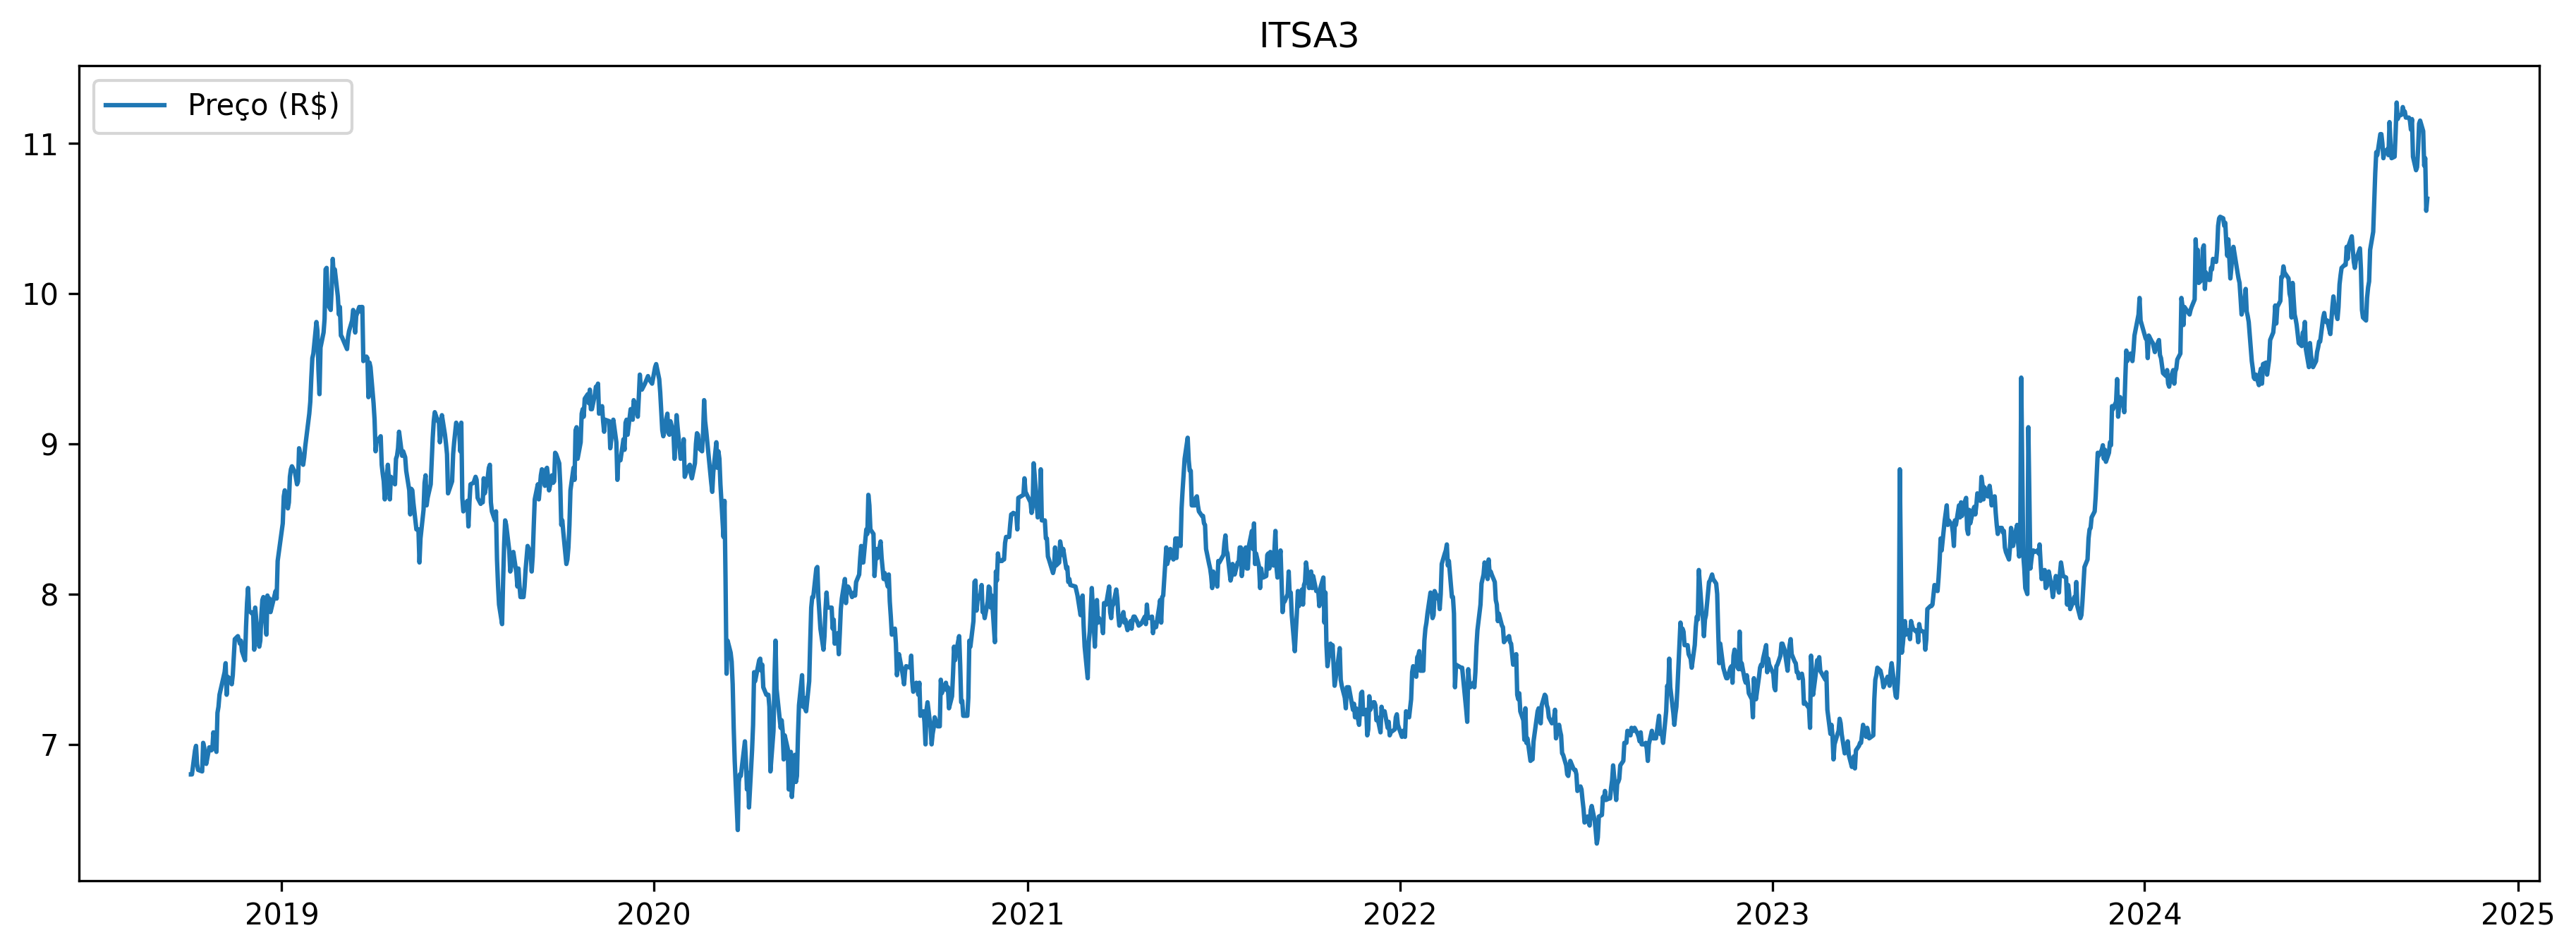

In [19]:
print_line_series(itsa3, "ITSA3")

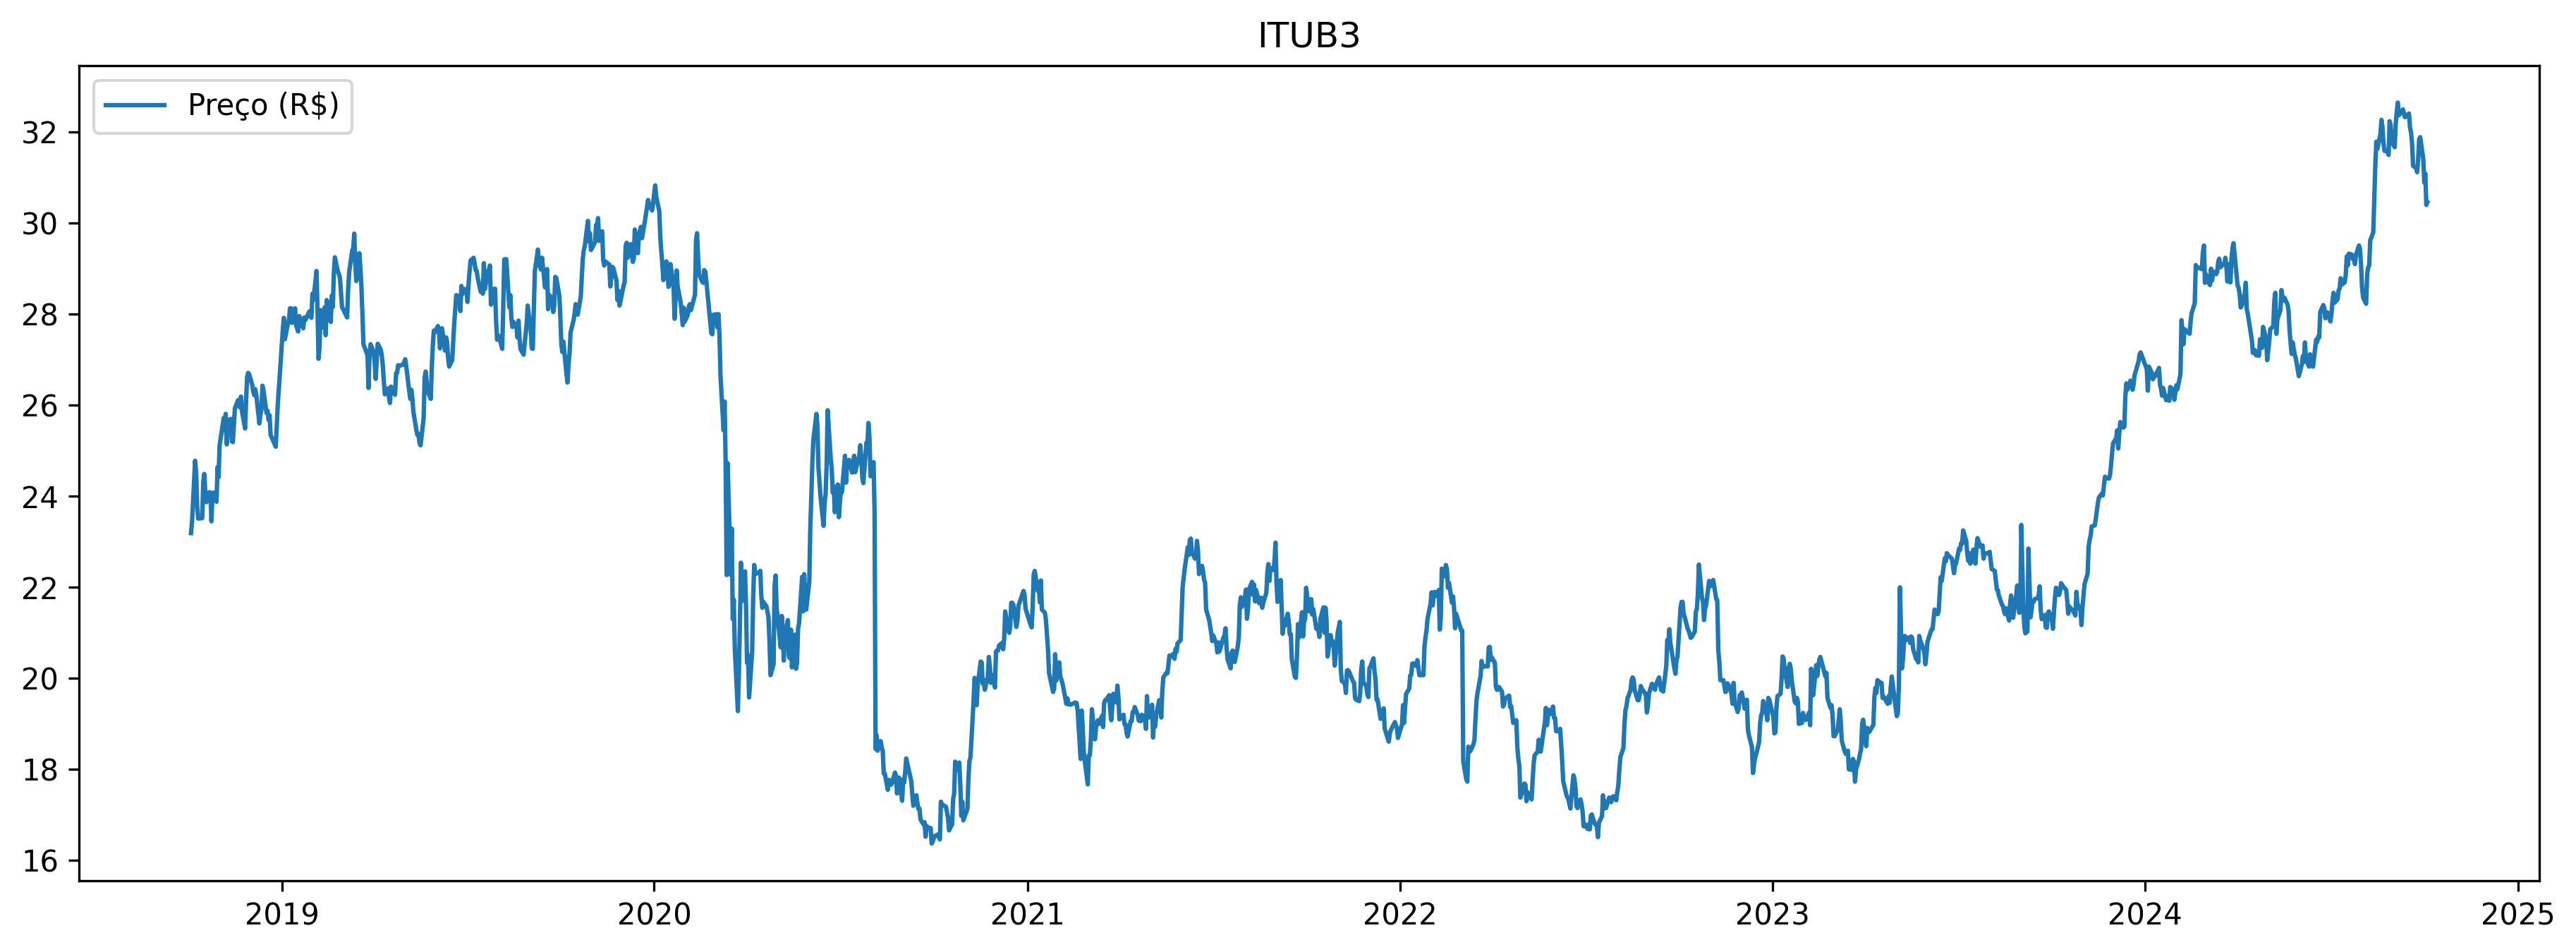

In [20]:
print_line_series(itub3, "ITUB3")

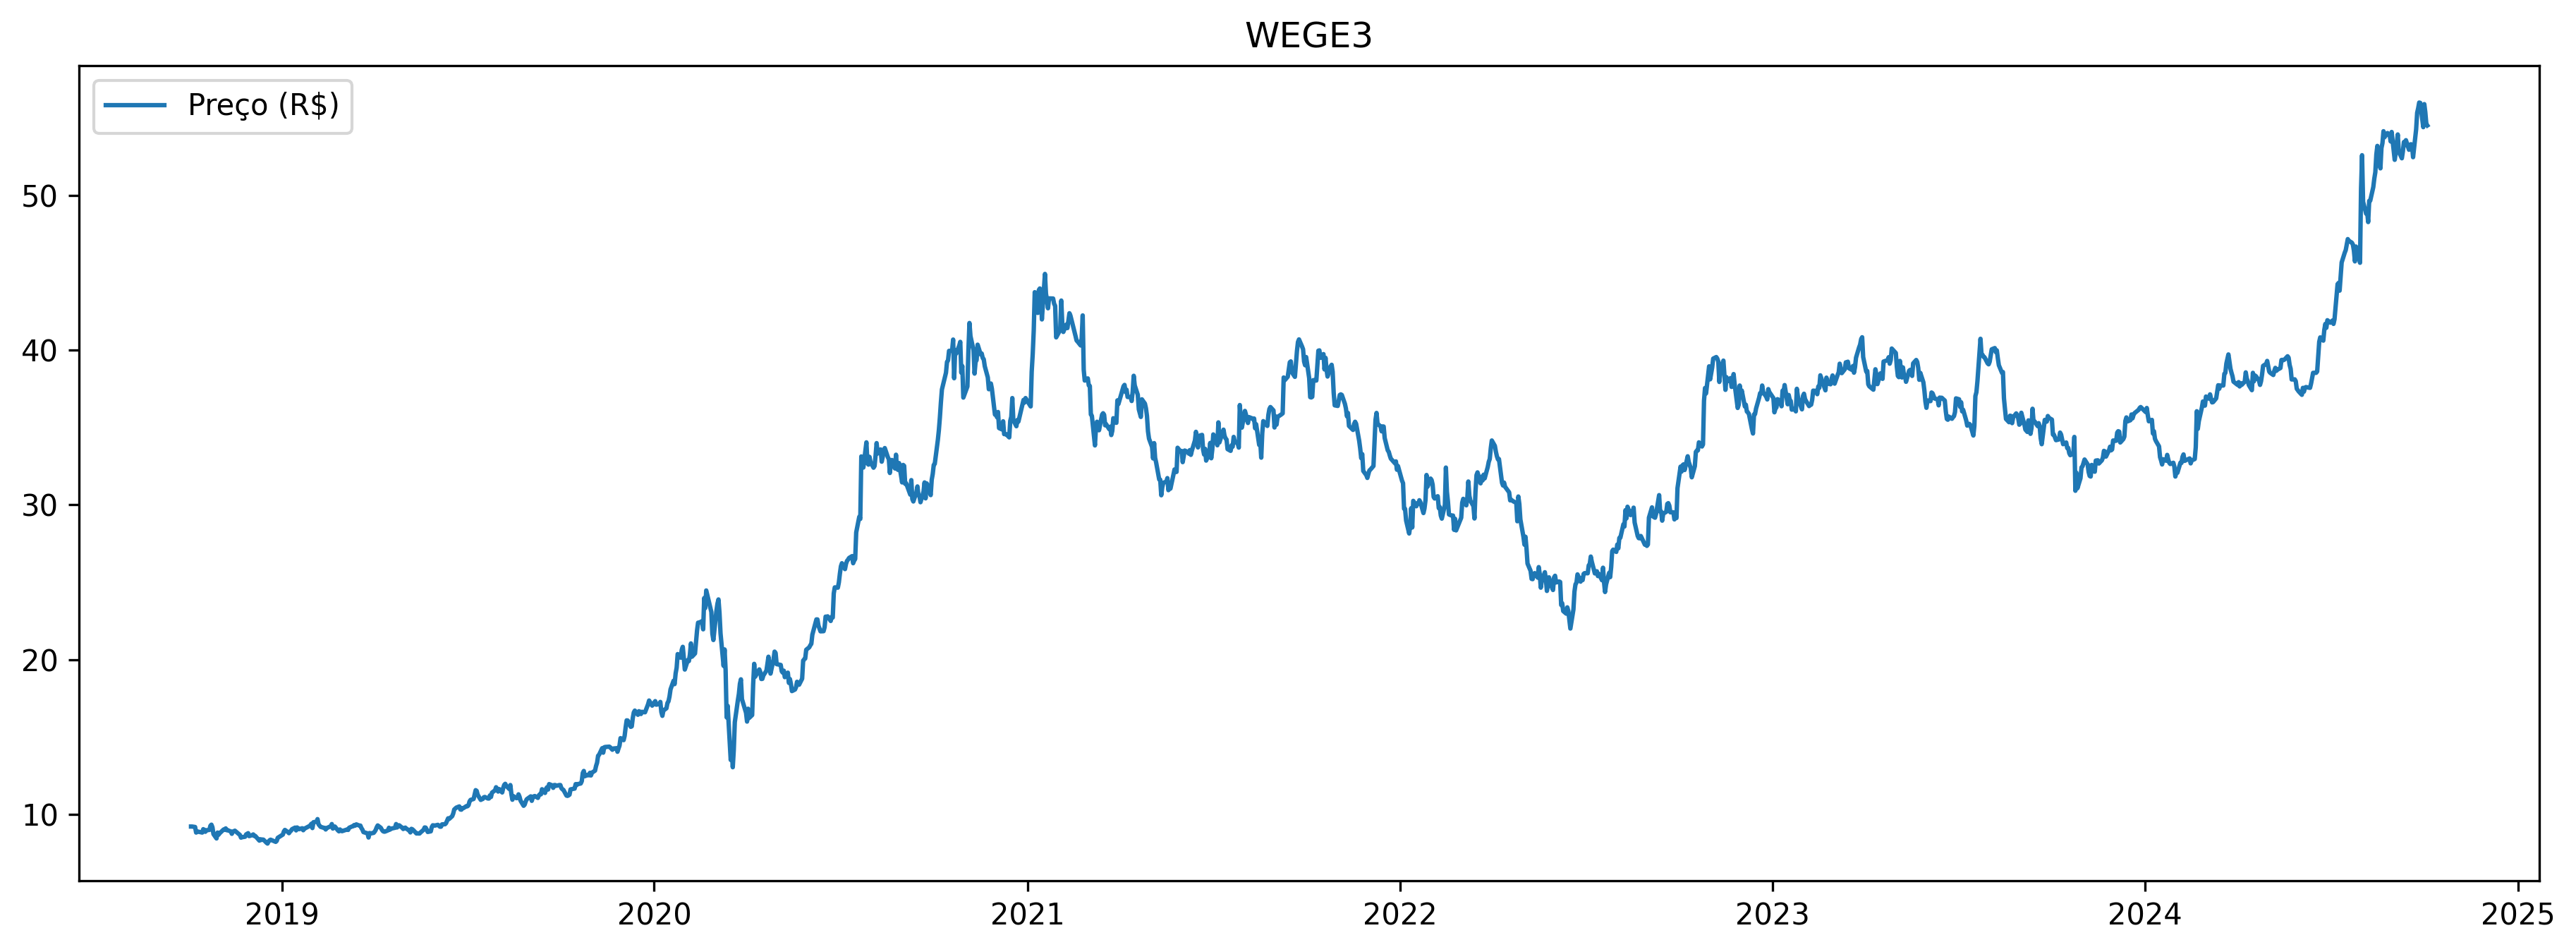

In [21]:
print_line_series(wege3, "WEGE3")

## Lidando com dados faltantes

In [22]:
abev3.isna().sum()

Price    0
dtype: int64

In [23]:
bbdc3.isna().sum()

Price    0
dtype: int64

In [24]:
itsa3.isna().sum()

Price    0
dtype: int64

In [25]:
itub3.isna().sum()

Price    0
dtype: int64

In [26]:
wege3.isna().sum()

Price    0
dtype: int64

In [27]:
print(len(abev3))
print(len(bbdc3))
print(len(itub3))
print(len(itsa3))
print(len(wege3))

1496
1497
1497
1497
1496


Não há NaN nas séries, mas há discrepâncias no eixo temporal. Concatenando os DFs irá juntar o eixo temporal de todos eles, e as séries que não houverem registros de dias específicos passaram a ter NaN

In [28]:
stocks_df = pd.concat(
    [
        abev3.add_suffix("_abev3"), 
        bbdc3.add_suffix("_bbdc3"), 
        itub3.add_suffix("_itub3"), 
        itsa3.add_suffix("_itsa3"), 
        wege3.add_suffix("_wege3")
    ], 
    axis=1
)
stocks_df.head(10)

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3
Date,,,,,
2018-10-04,14.37,15.22,23.19,6.80,9.21
2018-10-05,14.20,14.78,23.44,6.80,9.21
2018-10-08,14.48,15.56,24.78,6.96,9.18
2018-10-09,14.06,15.58,24.54,6.99,8.82
2018-10-10,13.83,14.91,23.79,6.87,8.87
2018-10-11,13.67,15.00,23.51,6.83,8.88
2018-10-15,13.62,15.15,23.52,6.82,8.82
2018-10-16,14.00,15.79,24.32,7.01,9.04
2018-10-17,13.71,15.80,24.49,6.98,8.99


In [29]:
stocks_df.isna().sum()

Price_abev3    1
Price_bbdc3    0
Price_itub3    0
Price_itsa3    0
Price_wege3    1
dtype: int64

In [30]:
for col in [col for col in stocks_df.columns.tolist() if "Price_" in col]:
    count_largest_missing_interval(df=stocks_df, column=col)

The length of the largest consecutive sequence of missing values in Price_abev3 is: 1
The time range for this sequence is from 2024-05-25 00:00:00 to 2024-05-25 00:00:00


No missing values found in the Price_bbdc3 time series.


No missing values found in the Price_itub3 time series.


No missing values found in the Price_itsa3 time series.


The length of the largest consecutive sequence of missing values in Price_wege3 is: 1
The time range for this sequence is from 2024-05-25 00:00:00 to 2024-05-25 00:00:00




Considerando que a série de preços de ações se comporta de forma visualmente semelhante a passeios aleatórios com inclinação positiva, a suposição de que o melhor modelo para prever o próximo passo é repetir o anterior não se aplica pois não contabiliza a tendência da série. Nesse caso, será aplicada uma interpolação linear, considerando que os valores ausentes não constituem intervalos maiores que 3 valores sequenciais. https://people.duke.edu/~rnau/Notes_on_the_random_walk_model--Robert_Nau.pdf


In [31]:
exploration_df = stocks_df.interpolate(method="linear")

In [32]:
exploration_df.isna().sum()

Price_abev3    0
Price_bbdc3    0
Price_itub3    0
Price_itsa3    0
Price_wege3    0
dtype: int64

## Exploração

In [33]:
exploration_df = compute_returns_for_prices(exploration_df, exploration_df.columns.tolist())
exploration_df.tail()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3
Date,,,,,,,,,,
2024-09-30,13.08,12.89,31.41,11.08,54.39,0.012384,-0.011503,-0.015052,-0.006278,-0.028056
2024-10-01,13.60,12.96,30.89,10.85,55.88,0.039755,0.005431,-0.016555,-0.020758,0.027395
2024-10-02,13.72,13.38,31.09,10.90,55.35,0.008824,0.032407,0.006475,0.004608,-0.009485
2024-10-03,13.40,13.25,30.40,10.55,54.60,-0.023324,-0.009716,-0.022194,-0.032110,-0.013550
2024-10-04,13.28,13.29,30.46,10.63,54.50,-0.008955,0.003019,0.001974,0.007583,-0.001832


### Estacionariedade

ADF Statistic: -17.722881410083588
p-value: 3.462006654855704e-30
H0 rejected for an alpha of 0.05. Series is possibly stationary
ADF Statistic: -10.750359125137742
p-value: 2.675065005031693e-19
H0 rejected for an alpha of 0.05. Series is possibly stationary
ADF Statistic: -11.933630587724078
p-value: 4.717822991338249e-22
H0 rejected for an alpha of 0.05. Series is possibly stationary
ADF Statistic: -18.086305751729306
p-value: 2.578007769140189e-30
H0 rejected for an alpha of 0.05. Series is possibly stationary
ADF Statistic: -26.218136320310066
p-value: 0.0
H0 rejected for an alpha of 0.05. Series is possibly stationary


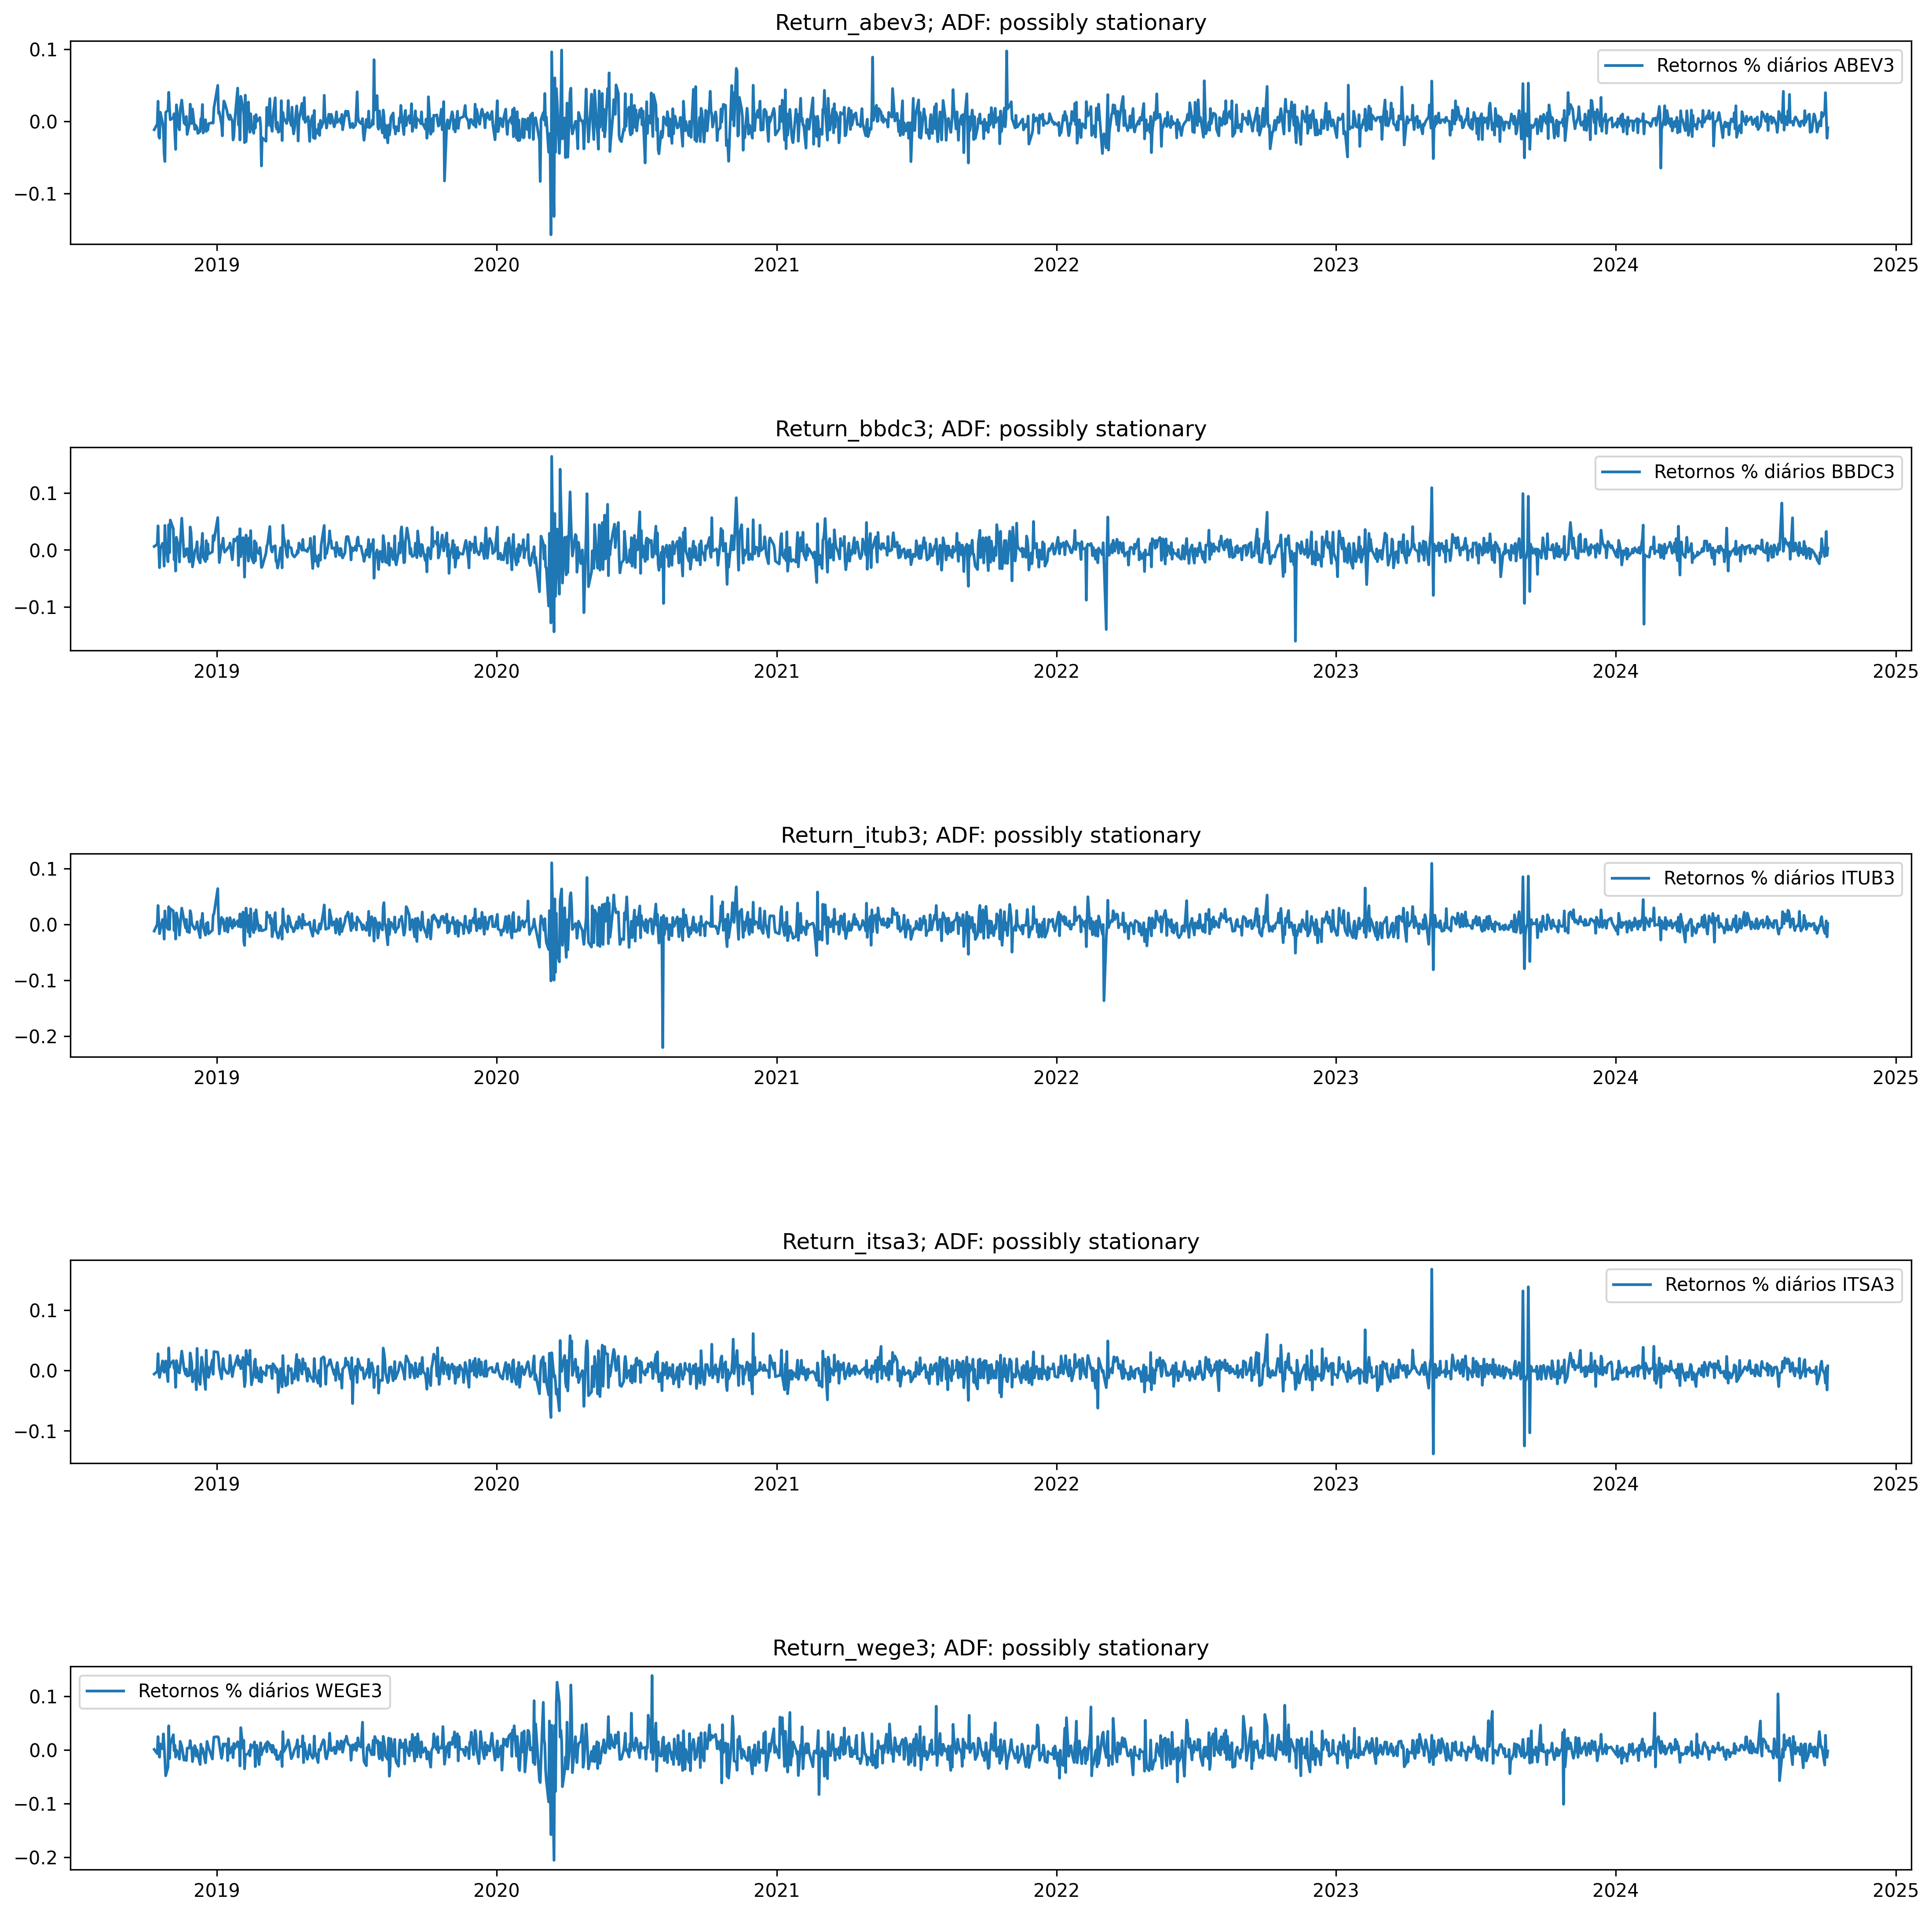

In [34]:
plt.figure(figsize=(18, 18))
for i, col in enumerate([col for col in exploration_df.columns.tolist() if "Return_" in col]):

    _, p_value = adf_test(exploration_df[col])

    plt.subplot(5, 1, i+1)
    plt.axis(True)
    plt.plot(exploration_df[col], label=f"Retornos % diários {col.split('_')[1].upper()}")
    plt.legend()
    plt.title(f"{col}; ADF: {'possibly stationary' if p_value < 0.05 else 'possibly non-stationary'}")
    plt.subplots_adjust(wspace=0.2, hspace=1.0)

O teste ADF com um alpha de 5% corrobora para todas as séries uma probabilidade próxima a 0 de observar séries como essas assumindo que ela são não-estacionárias, portanto, rejeitamos a hipótese nula de não-estacionariedade. Observa-se que as séries de retornos se comportam como séries de ruído, corroborando com o conhecimento da dificuldade de se trabalhar com esse tipo de série por causa da ínfima proporção sinal:ruído

### Autocorrelação

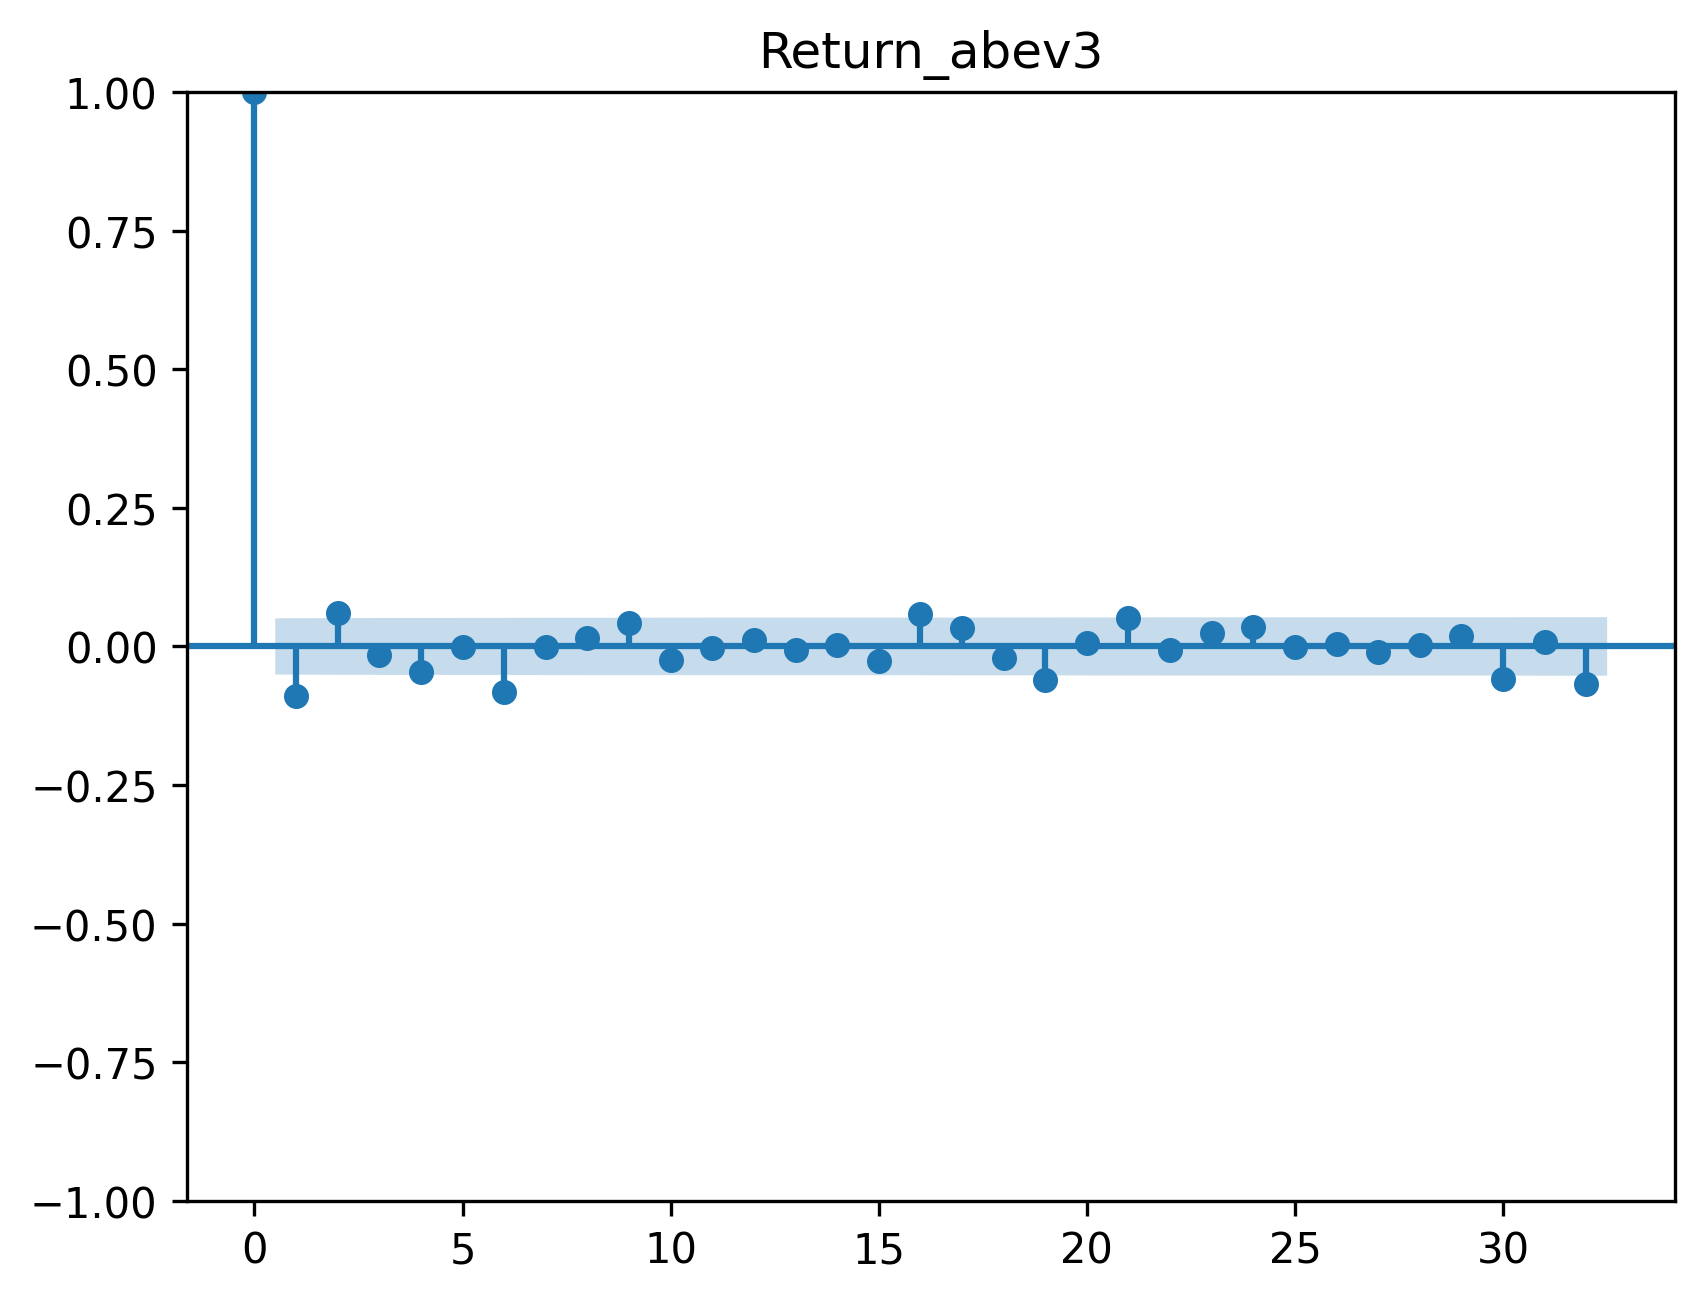

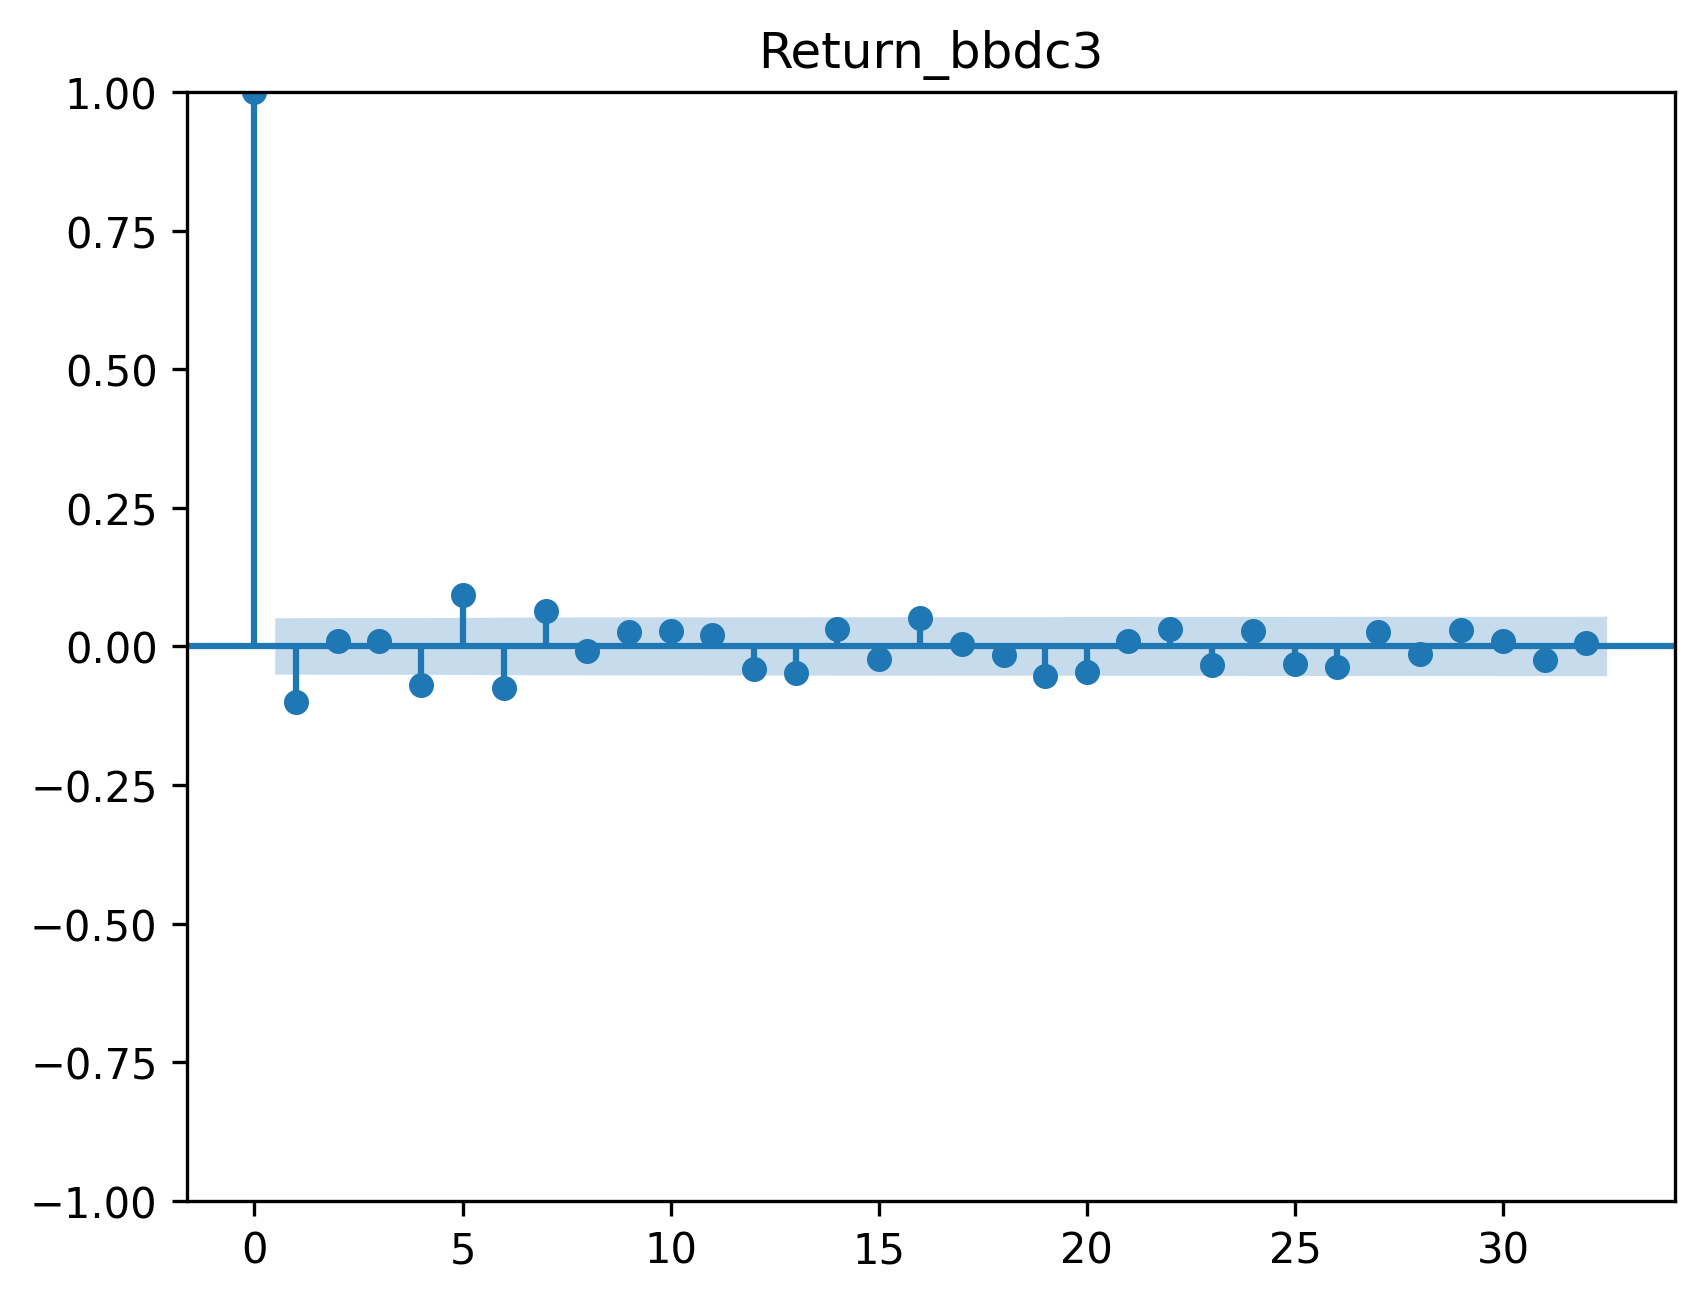

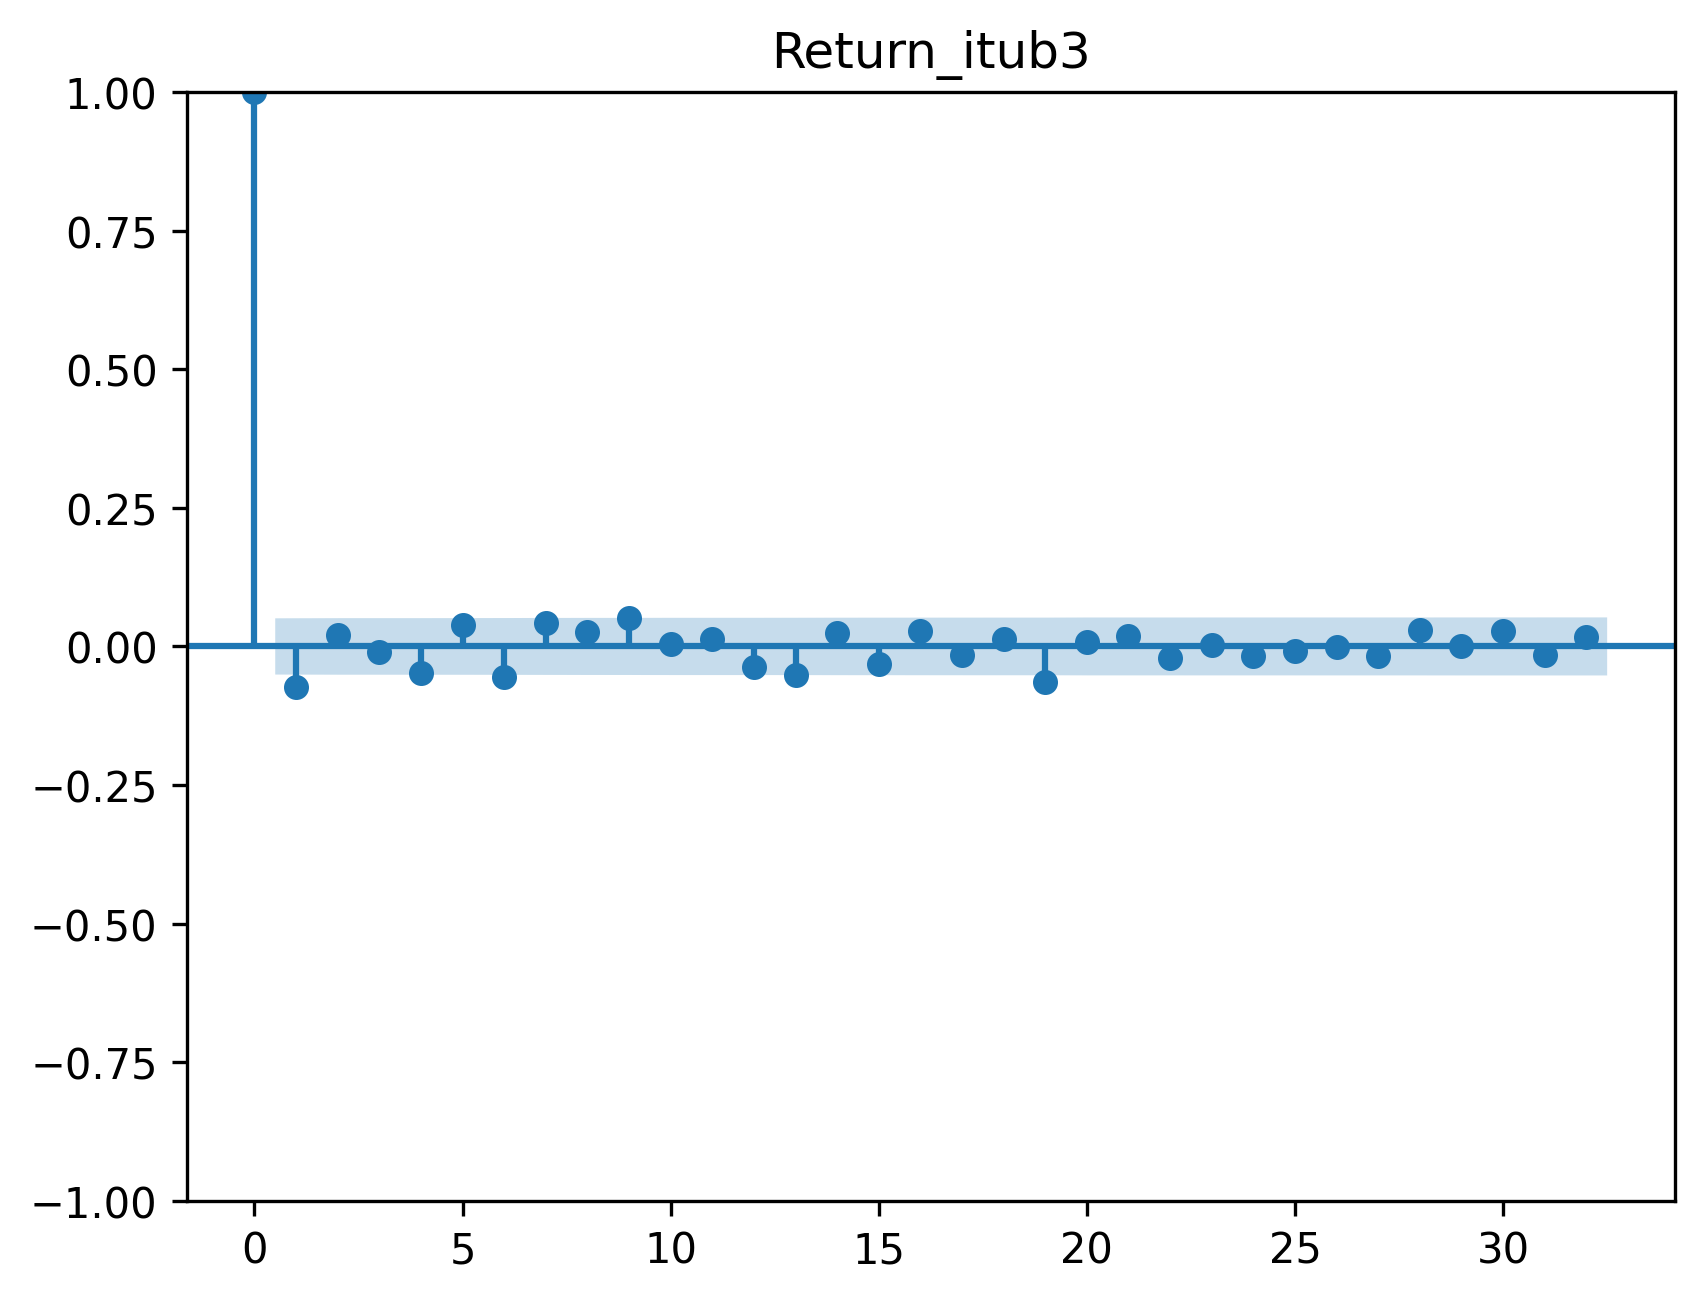

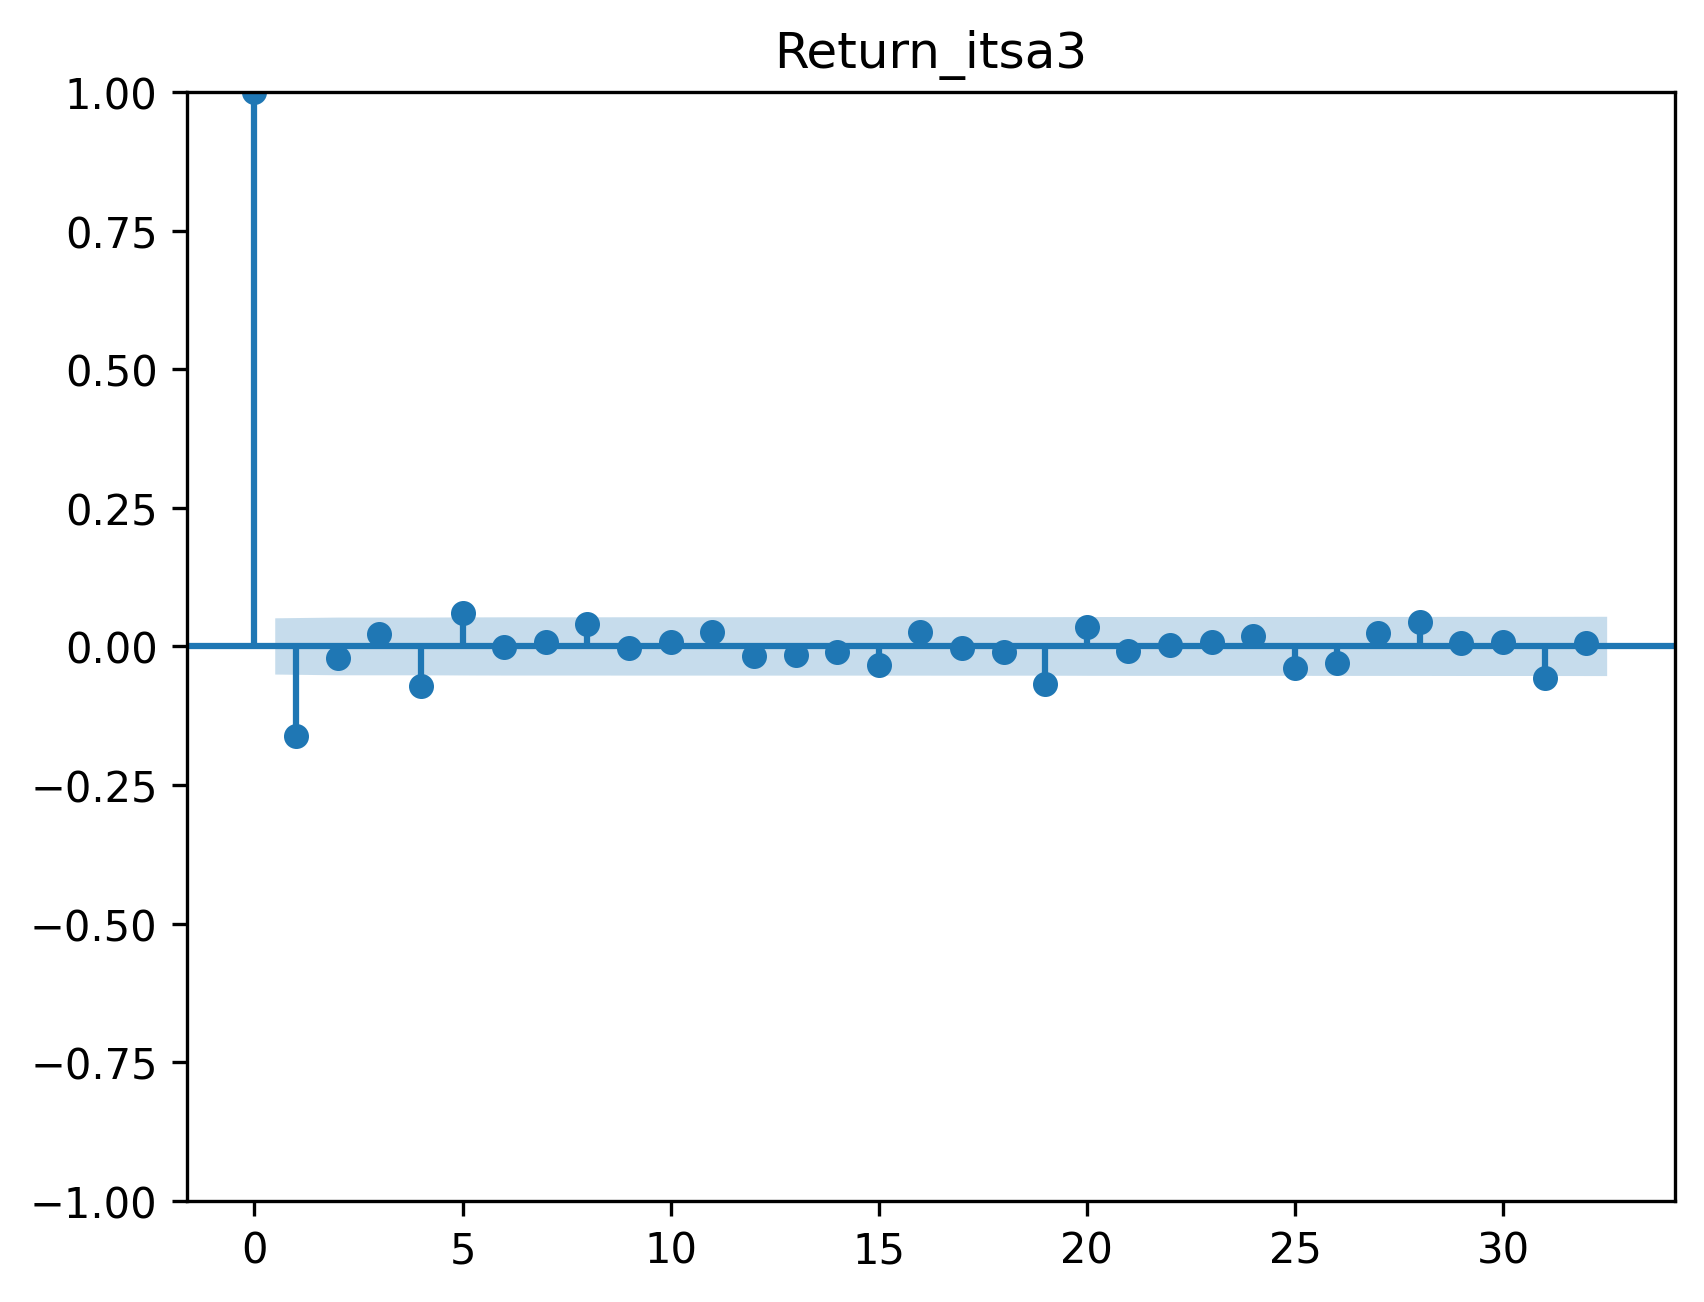

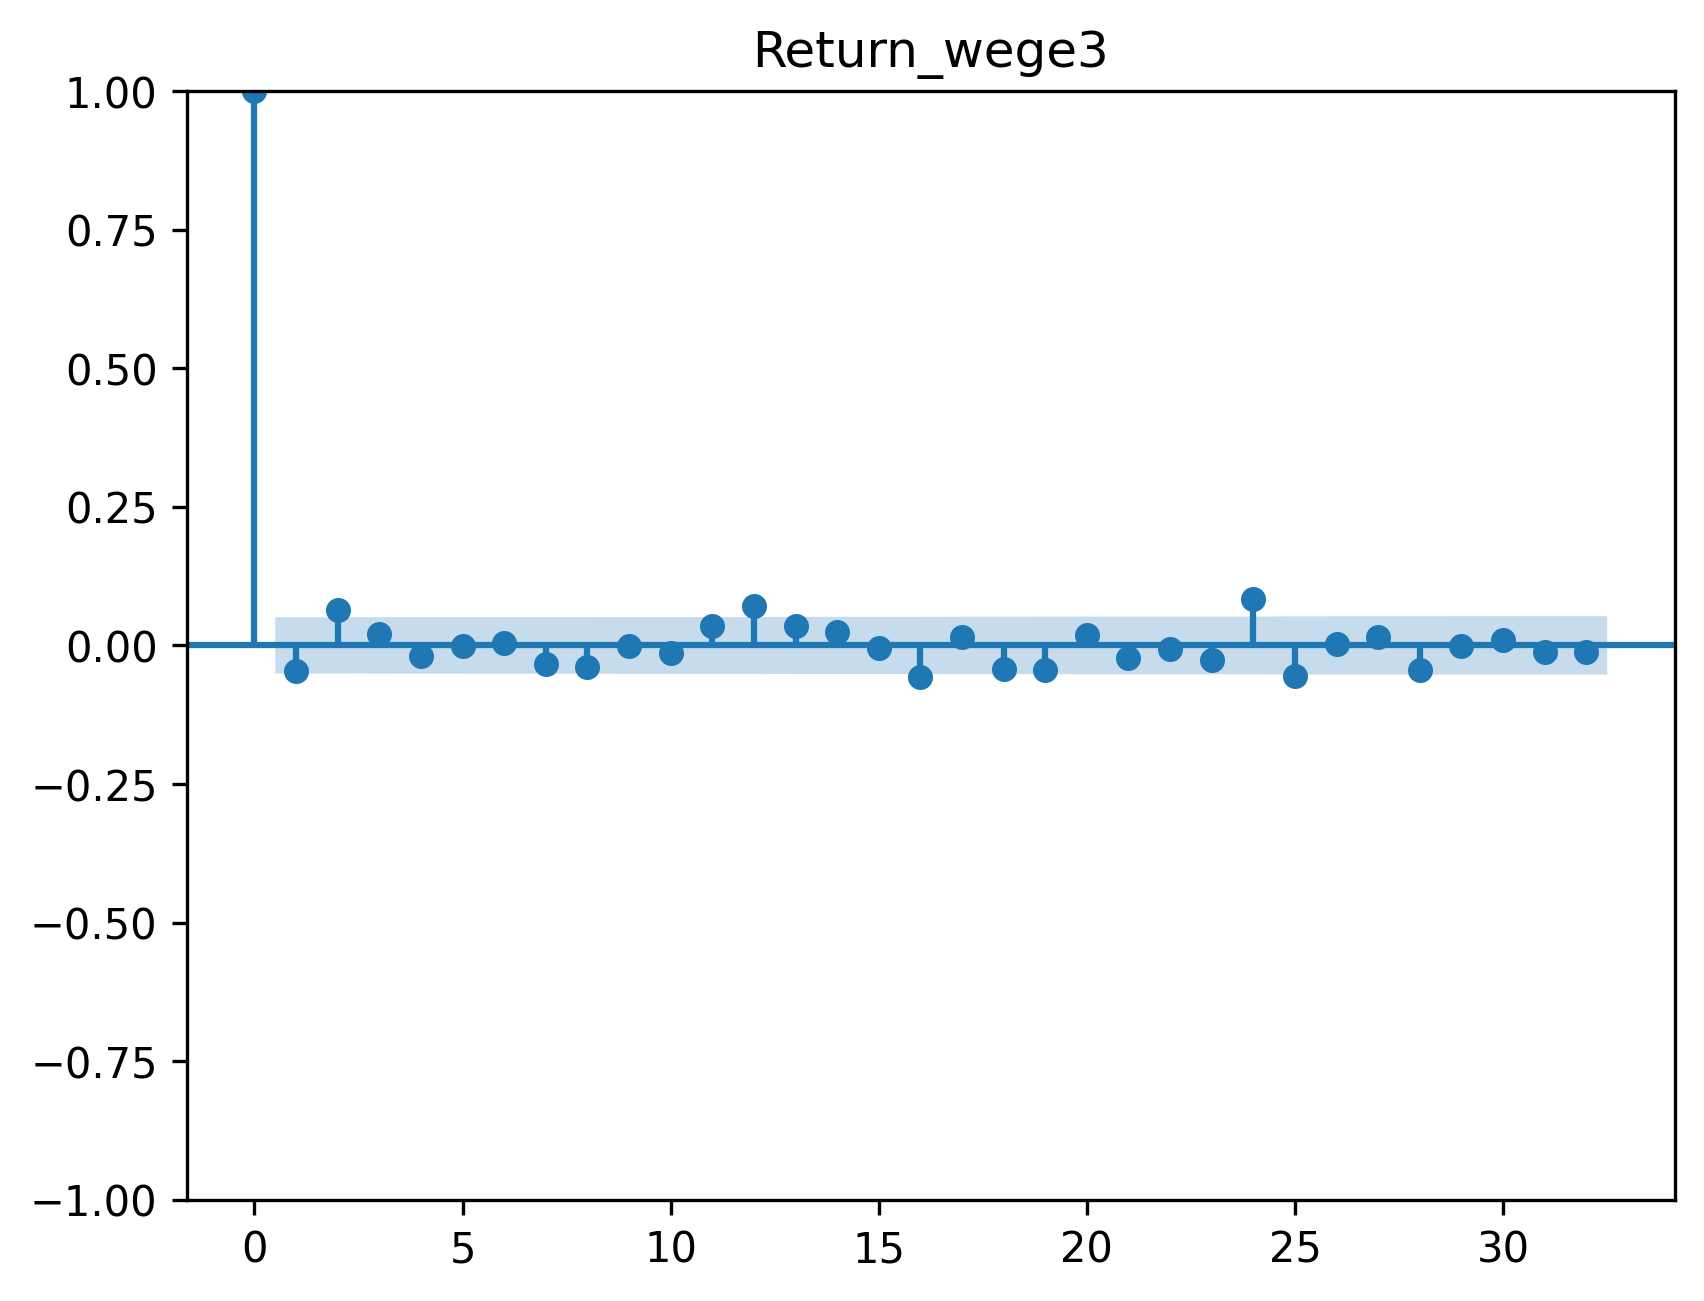

In [35]:
for i, col in enumerate([col for col in exploration_df.columns.tolist() if "Return_" in col]):
    plot_acf(exploration_df[col], title=col)
    plt.subplots_adjust(wspace=0.2, hspace=1.0)

As séries de retornos no geral não apresentam autocorrelação, exceto pela ITSA3 que apresenta um valor um pouco acima do limiar para o lag 1

In [36]:
return_cols_names = [col for col in exploration_df.columns.tolist() if "Return_" in col and "lag" not in col]

all_return_data = np.concatenate([exploration_df[col] for col in return_cols_names])
global_min_return = np.min(all_return_data)
global_max_return = np.max(all_return_data)

### Distribuições; Normalidade

Return_abev3
Shapiro-Wilk Statistic: 0.9296544833118904
P-Value: 6.643421111741264e-26
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal

Return_bbdc3
Shapiro-Wilk Statistic: 0.8934389936657088
P-Value: 6.285858444905597e-31
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal

Return_itub3
Shapiro-Wilk Statistic: 0.8872897107688986
P-Value: 1.212238609937015e-31
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal

Return_itsa3
Shapiro-Wilk Statistic: 0.8862407500525595
P-Value: 9.220167410049507e-32
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal

Return_wege3
Shapiro-Wilk Statistic: 0.9189829444906941
P-Value: 1.4673404369821904e-27
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal



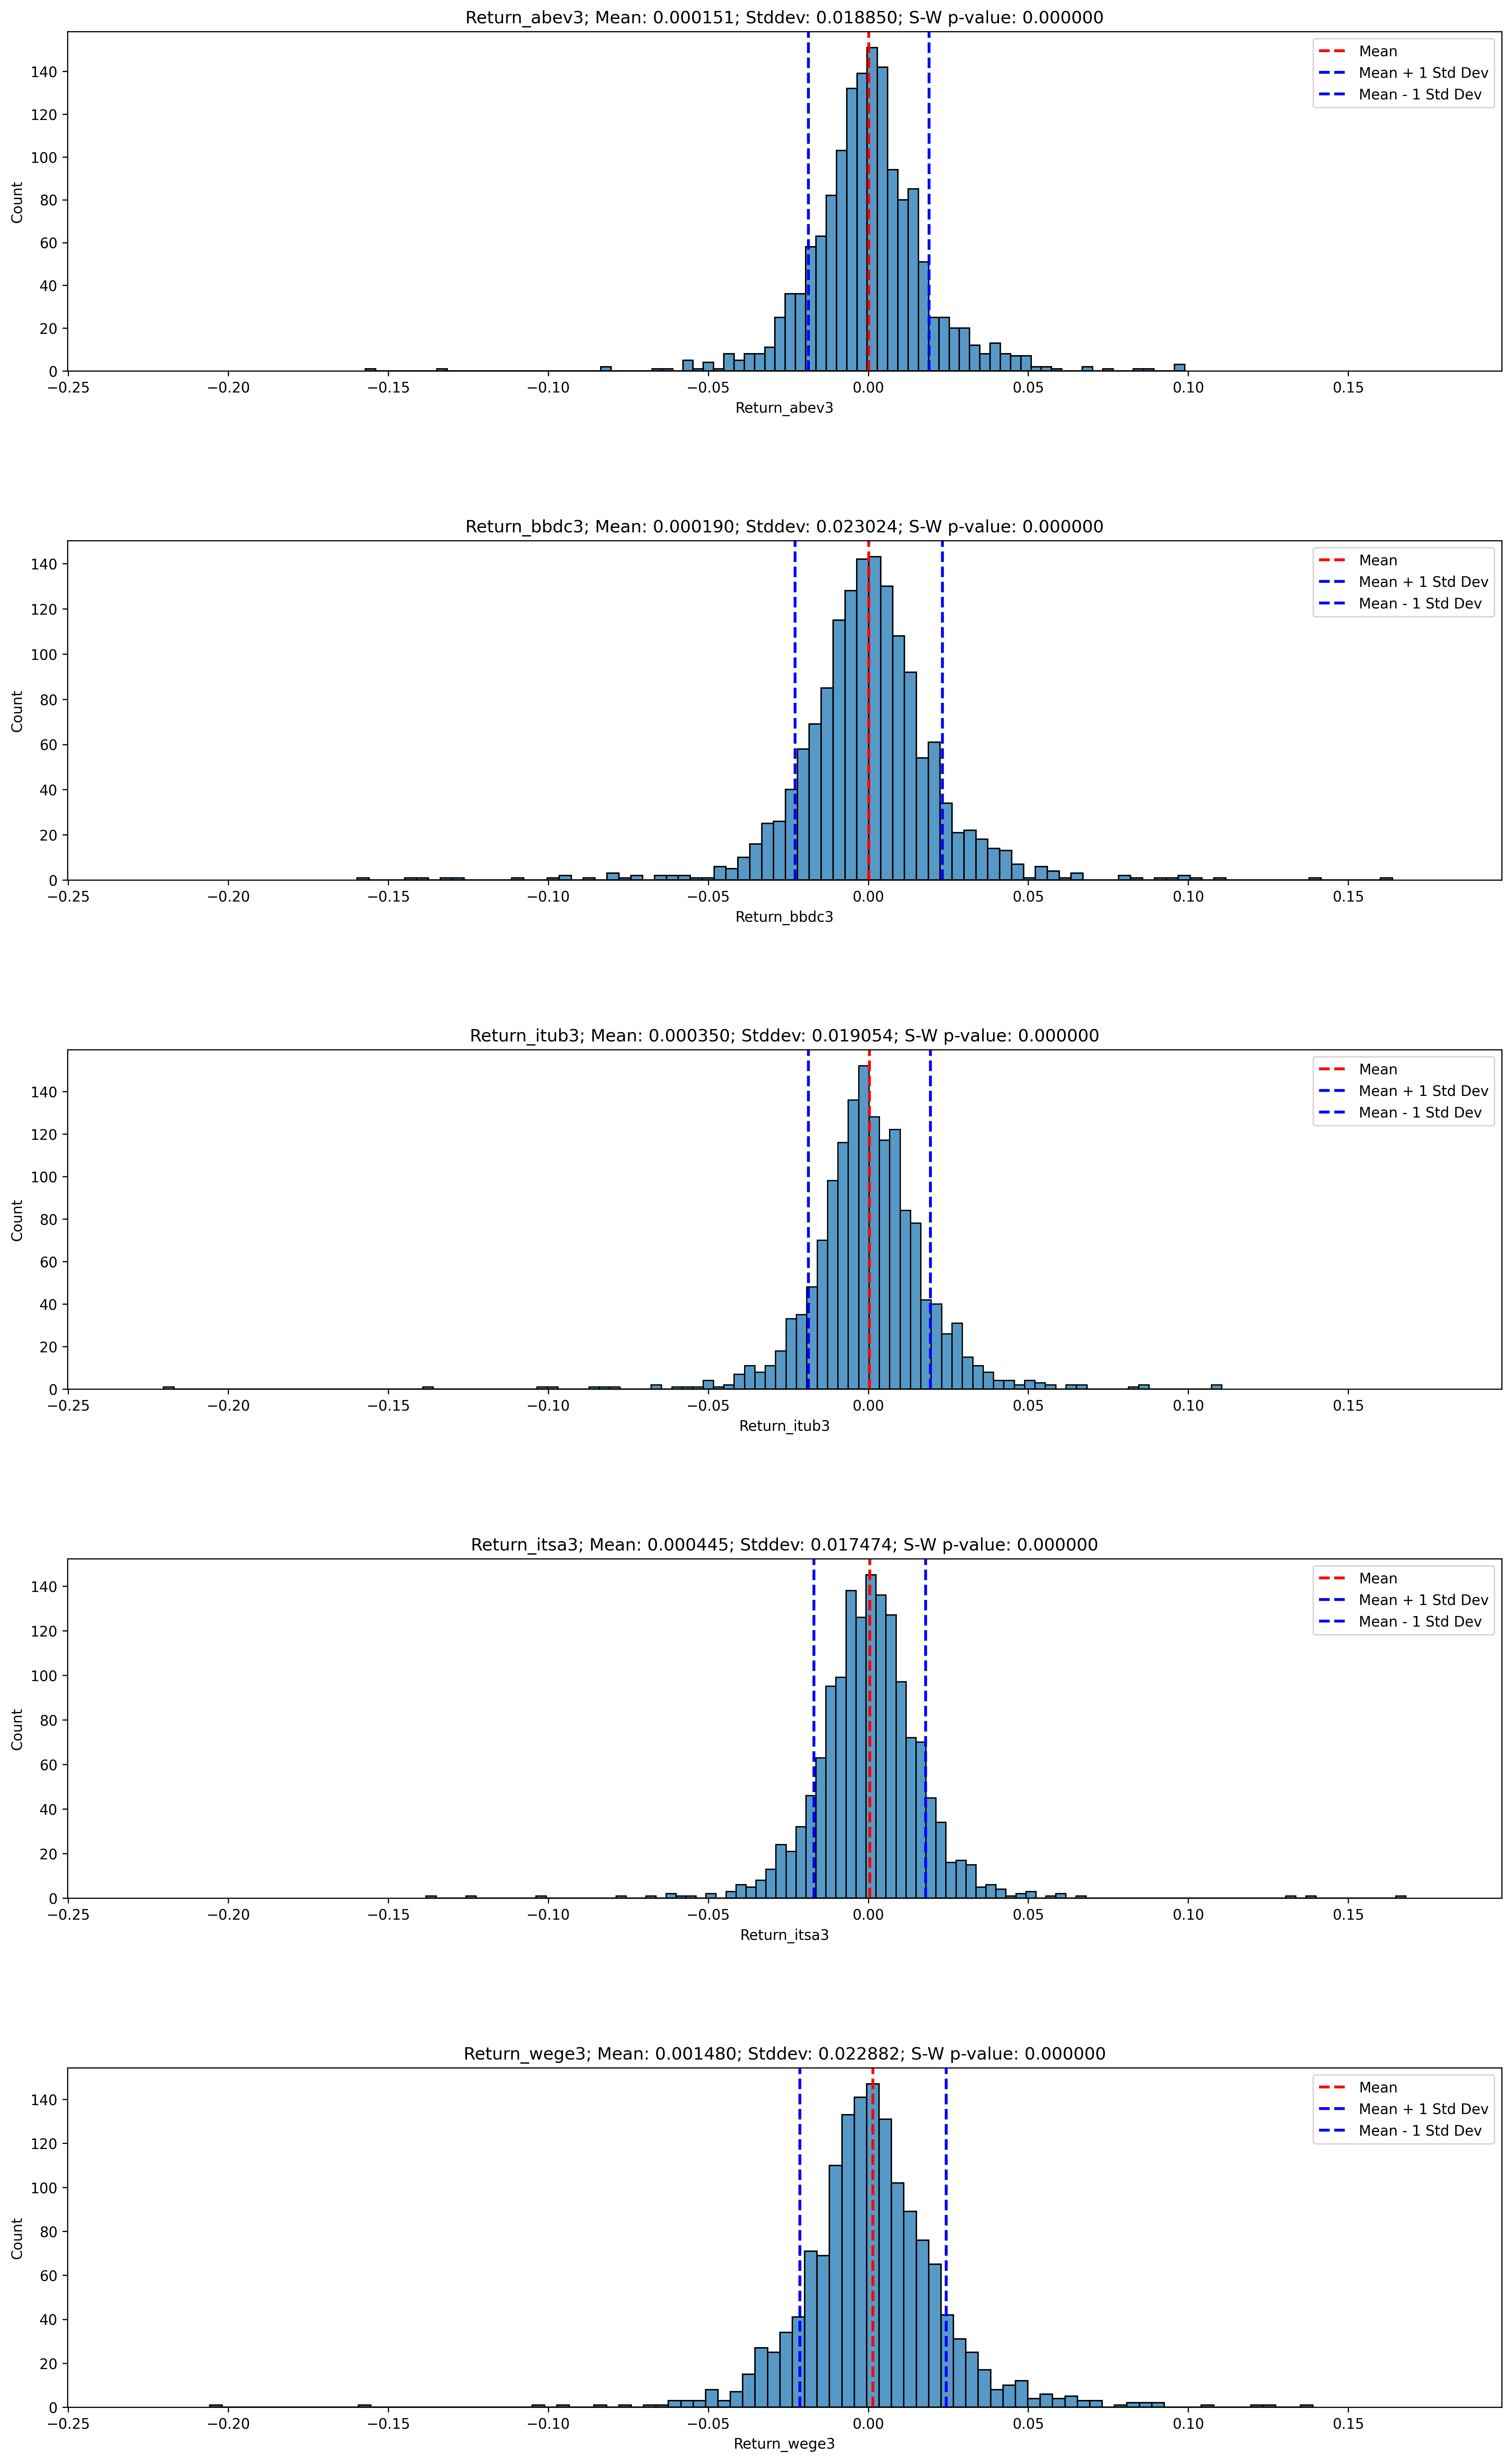

In [37]:
plt.figure(figsize=(18, 30))
for i, col in enumerate(return_cols_names):

    print(col)
    _, p_value = shapiro_wilk_gaussian_test(exploration_df[col])
    print("")

    mean = np.array(exploration_df[col]).mean()
    std = np.array(exploration_df[col]).std()

    plt.subplot(5, 1, i+1)
    plt.axis(True)
    sns.histplot(data=exploration_df, x=col, kde=False)
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean')
    plt.axvline(mean + std, color='blue', linestyle='dashed', linewidth=2, label=f'Mean + 1 Std Dev')
    plt.axvline(mean - std, color='blue', linestyle='dashed', linewidth=2, label=f'Mean - 1 Std Dev')
    plt.title(f"{col}; Mean: {mean:.6f}; Stddev: {std:.6f}; S-W p-value: {p_value:.6f}")
    plt.legend(frameon=True)
    plt.xlim(global_min_return - 0.03, global_max_return + 0.03)
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

Análise dos histogramas corrobora com a observação de que os dados não seguem uma distribuição normal de acordo com o teste de Shapiro-Wilk, possivelmente por causa da grande quantidade de outliers que puxam as caudas da distribuição para ambos os lados

### Correlações entre séries

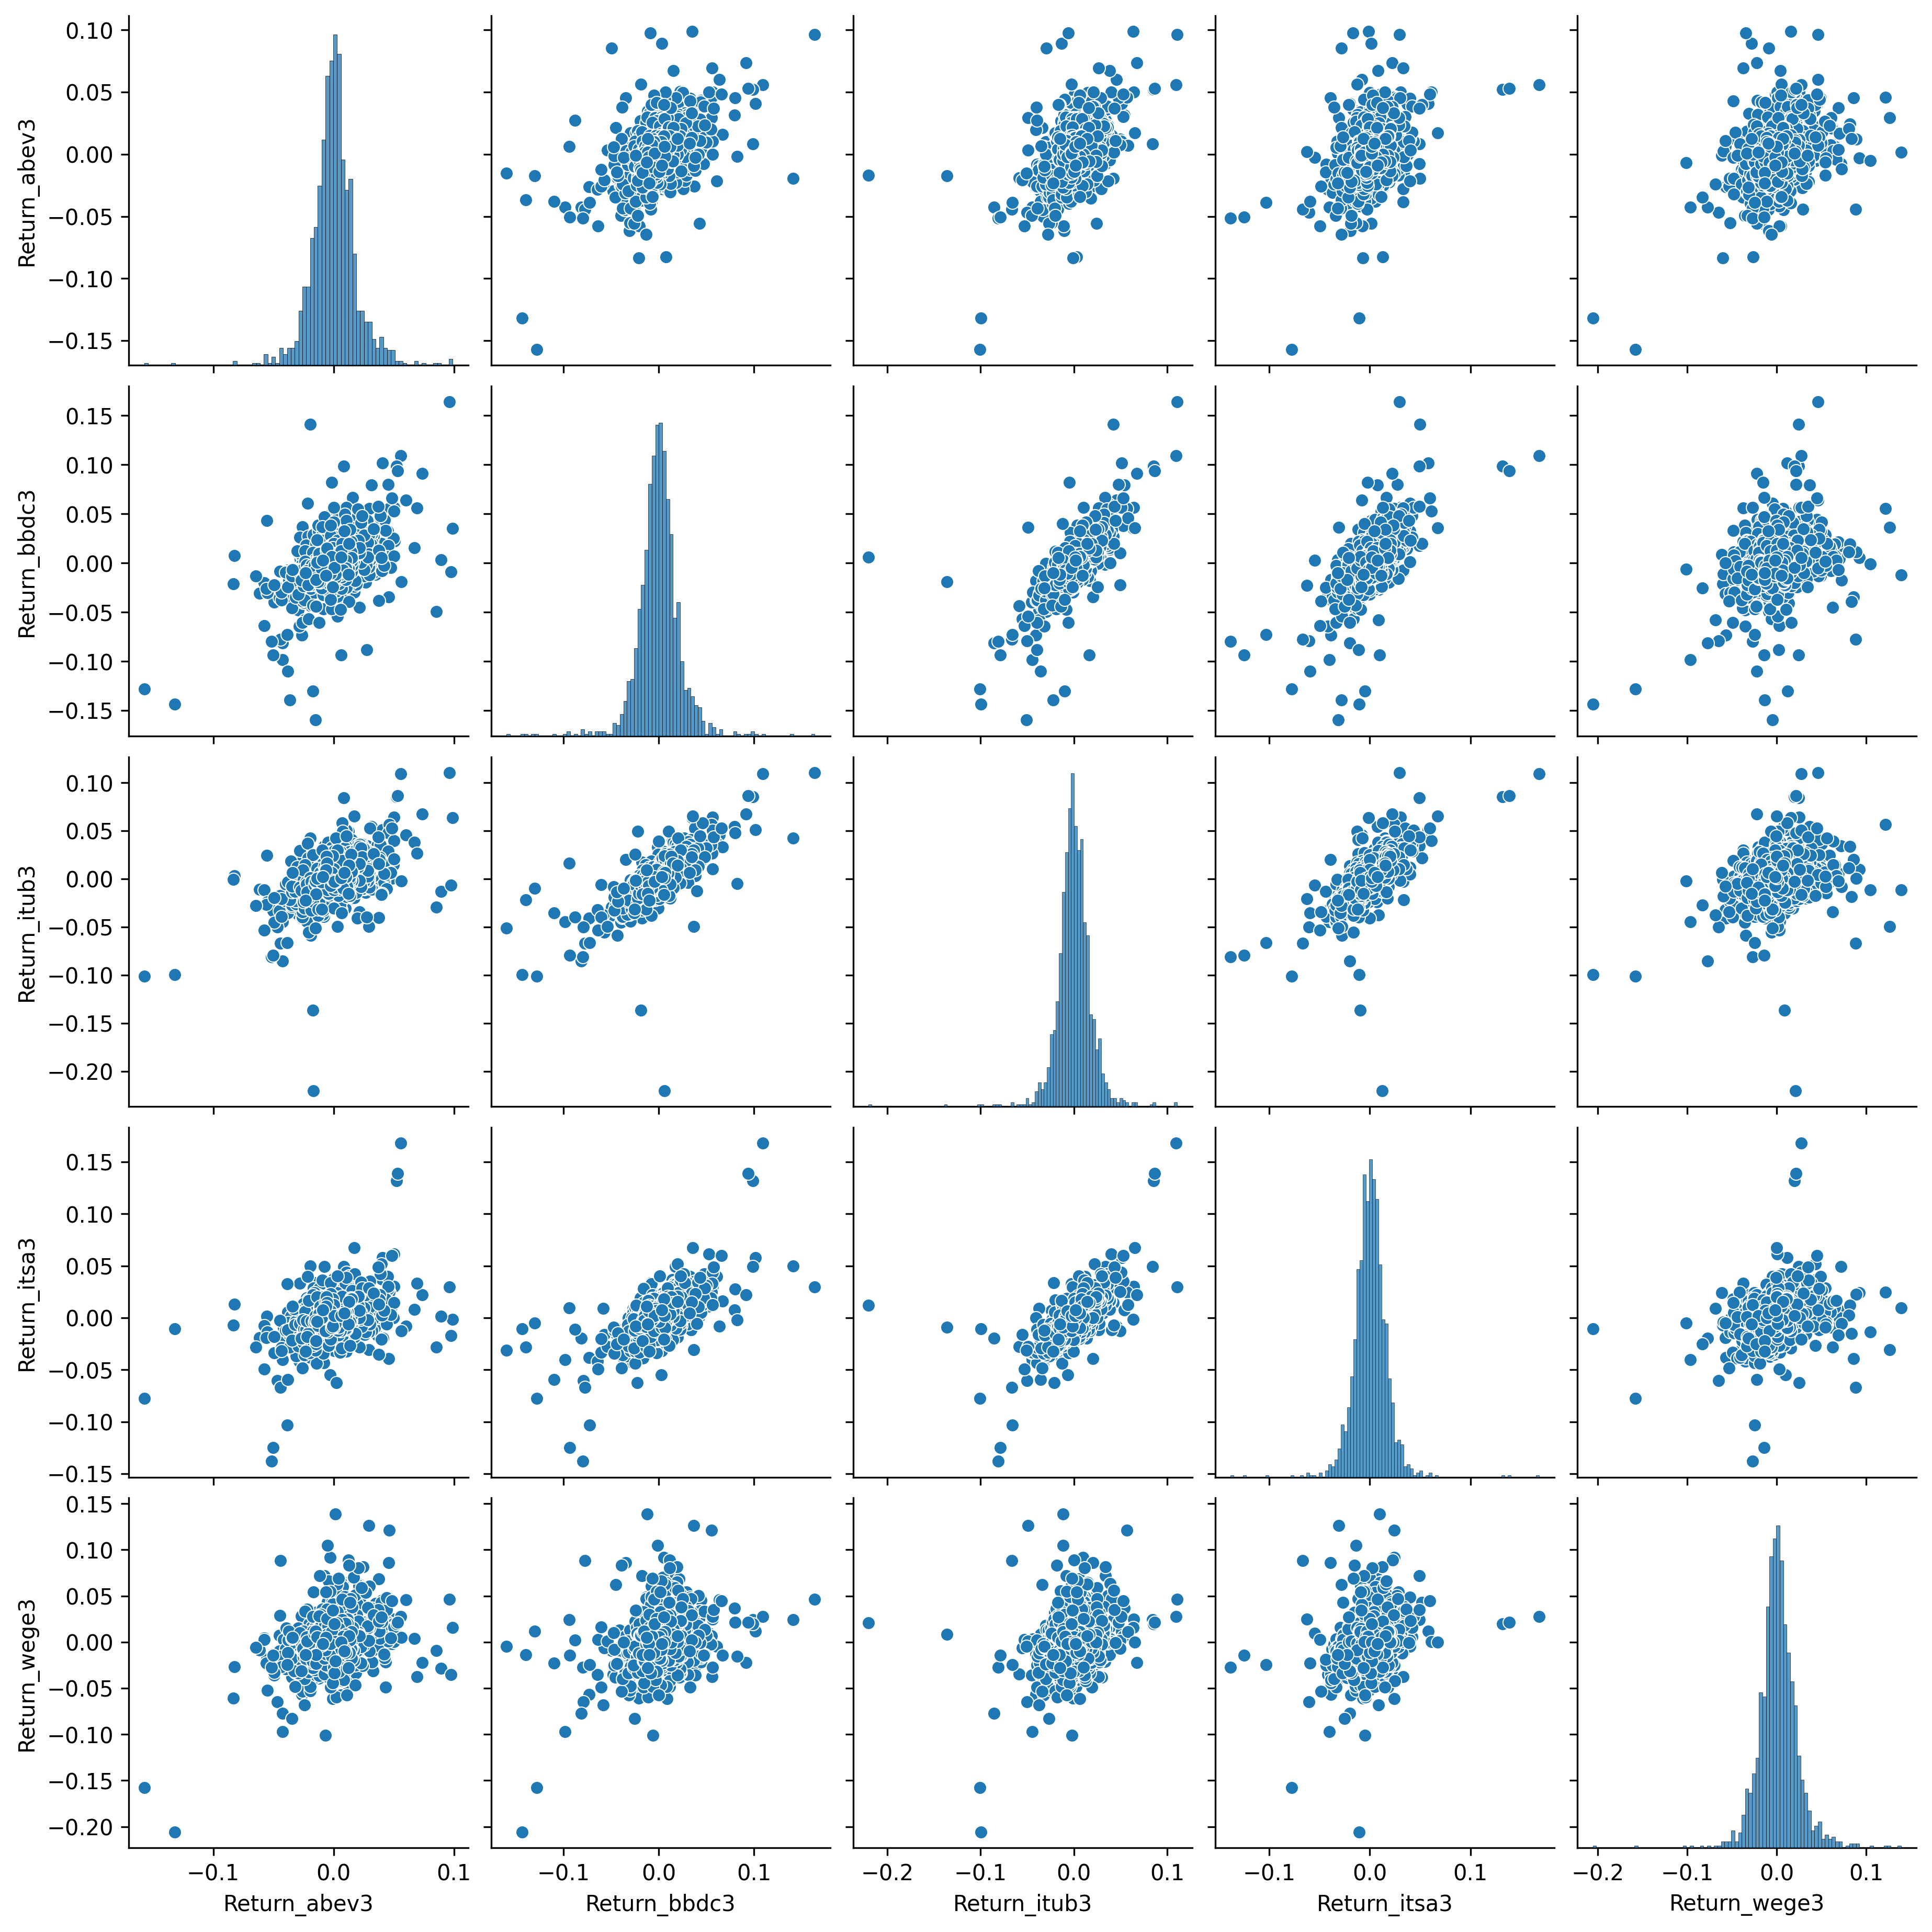

In [38]:
sns.pairplot(exploration_df[[col for col in exploration_df.columns.tolist() if "Return" in col]])

<Axes: >

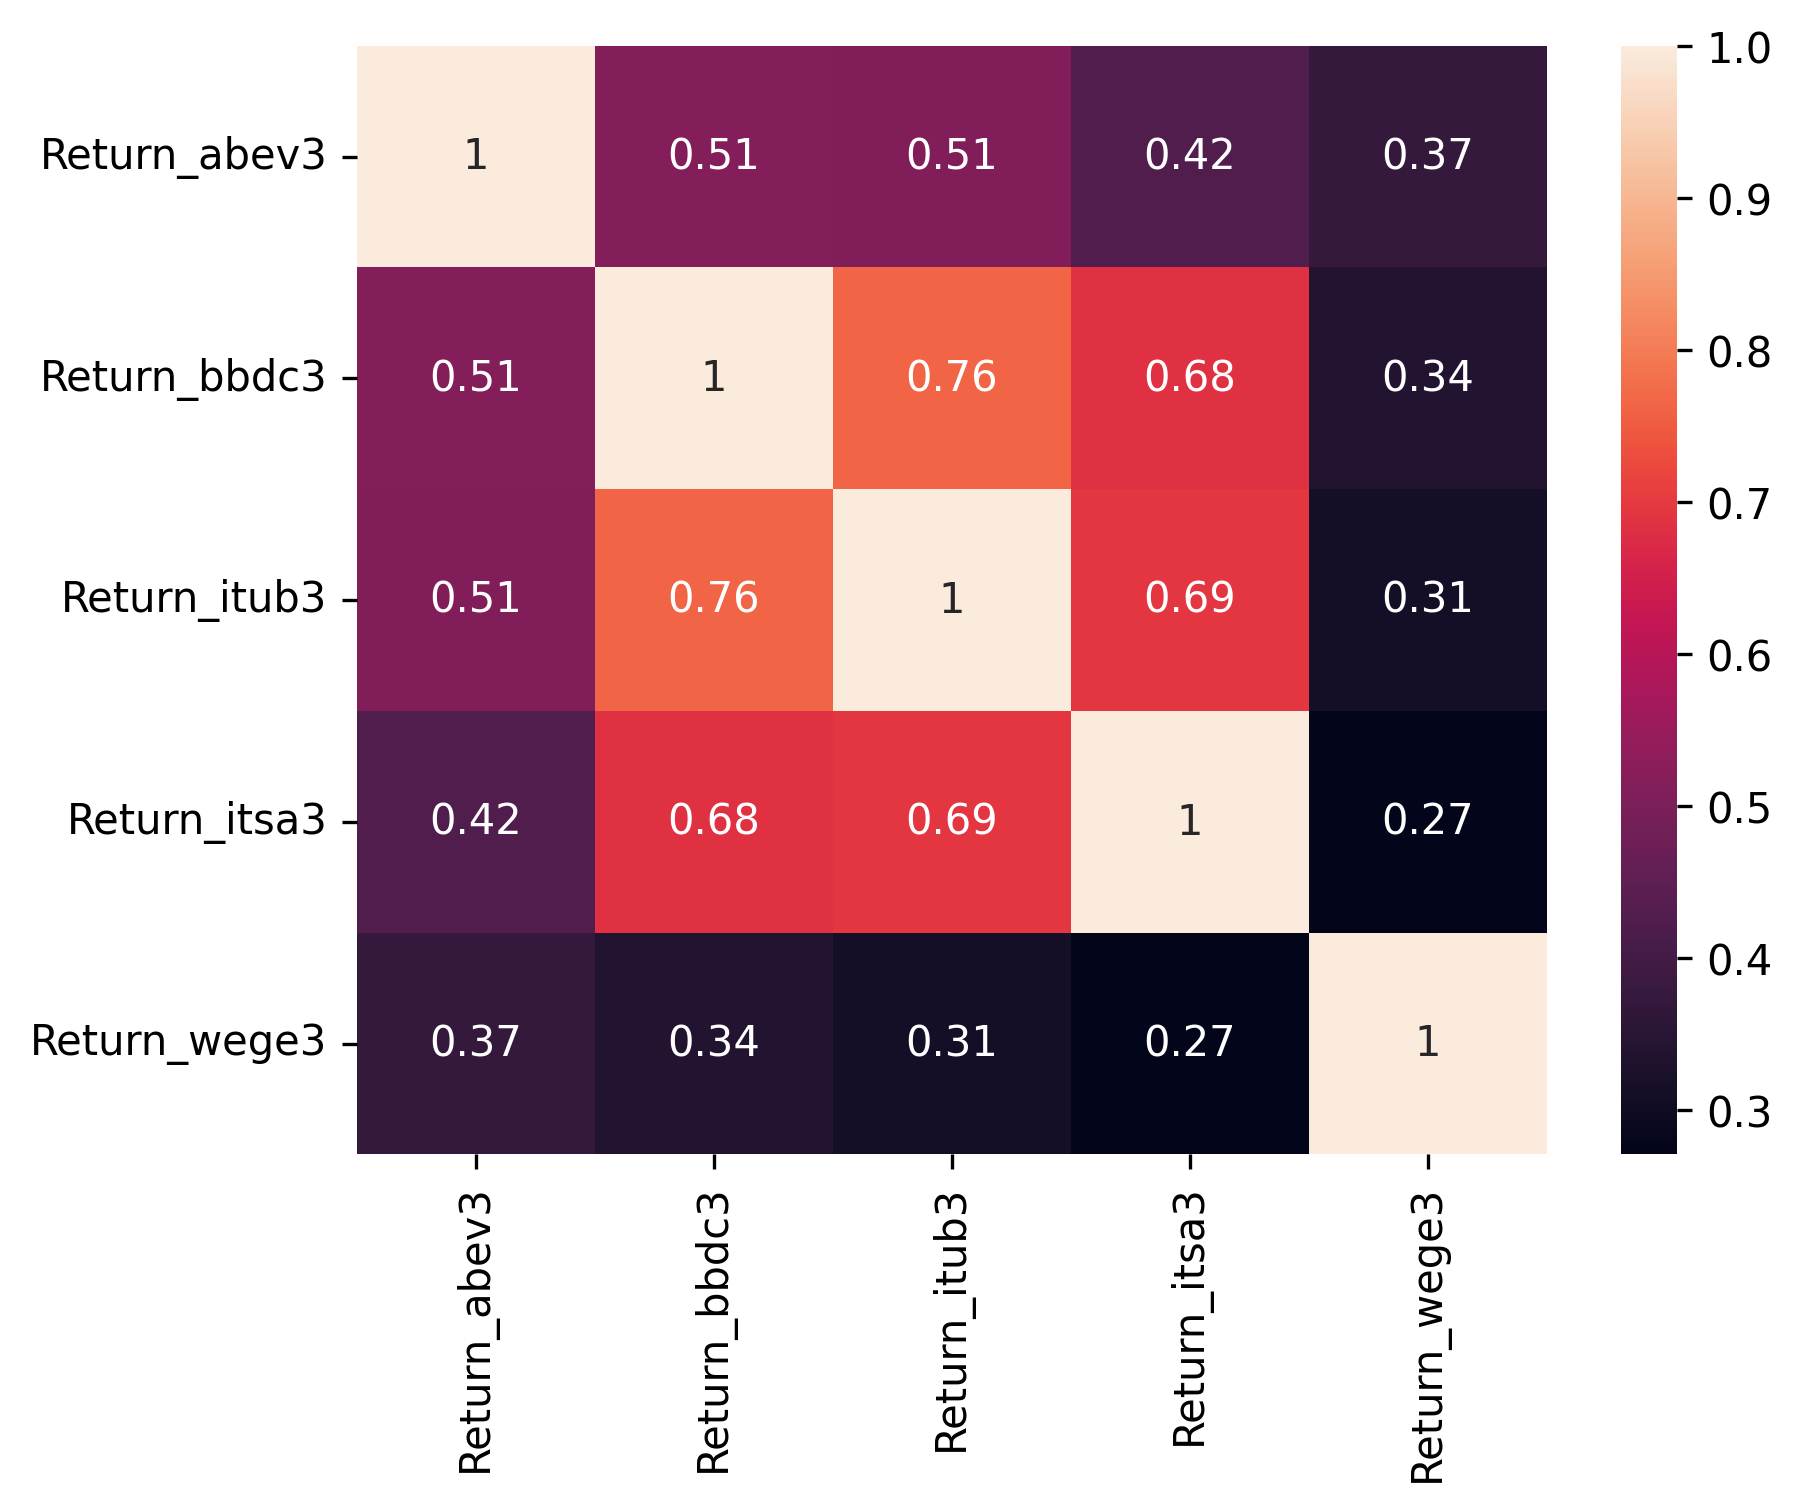

In [39]:
sns.heatmap(exploration_df[[col for col in exploration_df.columns.tolist() if "Return" in col]].corr(), annot=True)

O pairplot e o heatmap de correlação apontam que dificilmente qualquer uma série de retornos teria poder preditivo linear sobre as outras por não apresentarem uma correlação de Pearson significativa, exceto itub3 e bbdc3, o que faz sentido pois são duas ações do mesmo setor bancário, então movimentos de mercado que podem afetar uma delas também pode afetar a outra.

In [40]:
exploration_df[return_cols_names].describe()

,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,0.000151,0.000190,0.000350,0.000445,0.001480
std,0.018857,0.023032,0.019060,0.017480,0.022889
min,-0.157168,-0.159763,-0.220203,-0.138165,-0.205761
25%,-0.009162,-0.010617,-0.008981,-0.008744,-0.009973
50%,0.000000,0.000000,0.000000,0.000000,0.000540
75%,0.009333,0.010868,0.009662,0.009243,0.012163
max,0.098879,0.163800,0.110463,0.167989,0.138927


As séries de retornos são todas estacionárias e não seguem uma distribuição normal, de acordo com o teste ADF e o teste de Shapiro-Wilk, com uma média ligeiramente inclinada para o lado positivo. A média positiva indica que essas séries geraram retornos positivos com mais frequência do que negativos, e comprar e manter essas ações durante esse período resultaria, ao final, em um resultado financeiro positivo (isso não quer dizer que o resultado financeiro seja satisfatório). Todas as séries têm outliers bem acima e abaixo dos limites, o que pode estar influenciando o teste de Shapiro-Wilk a rejeitar a nula

### Correlação da série de preços vs Série de retornos

corr between Price_abev3 and itself lagged: PearsonRResult(statistic=0.9852213918157748, pvalue=0.0)
corr between Price_bbdc3 and itself lagged: PearsonRResult(statistic=0.9950013766158065, pvalue=0.0)
corr between Price_itub3 and itself lagged: PearsonRResult(statistic=0.9944834389129712, pvalue=0.0)
corr between Price_itsa3 and itself lagged: PearsonRResult(statistic=0.9901603572004416, pvalue=0.0)
corr between Price_wege3 and itself lagged: PearsonRResult(statistic=0.99830496544521, pvalue=0.0)


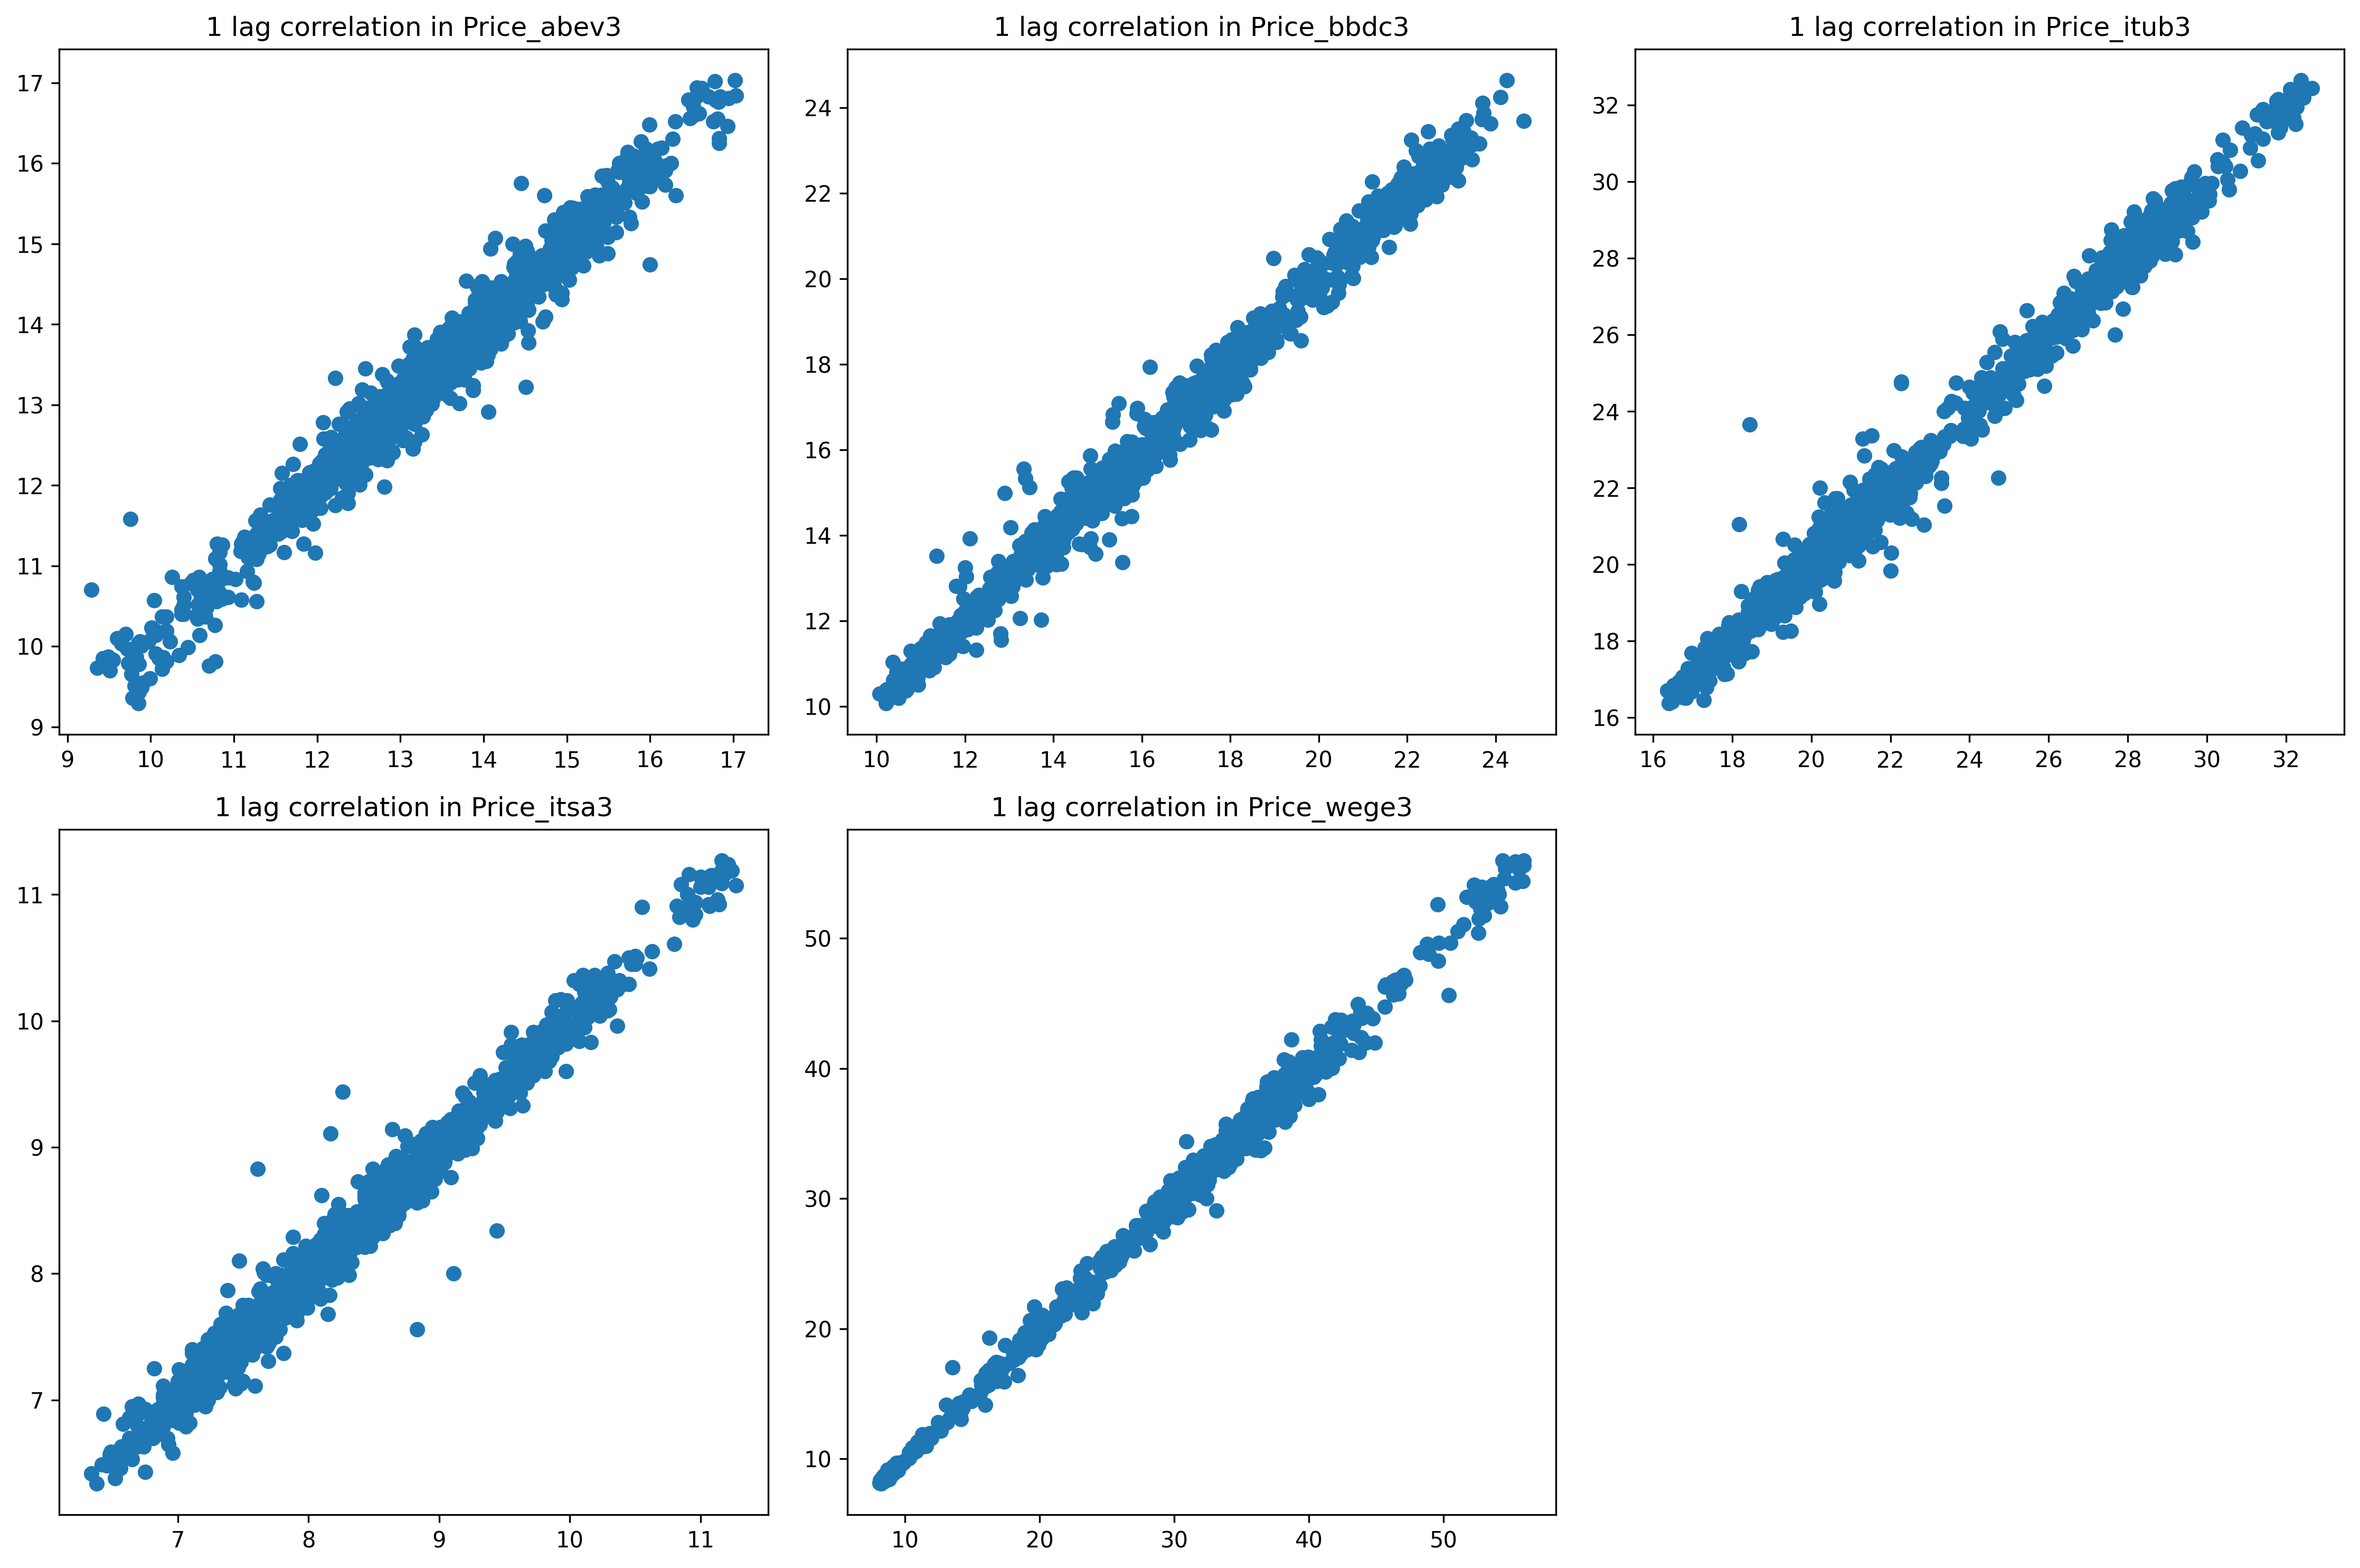

In [41]:
price_cols = [col for col in exploration_df.columns.tolist() if "Price" in col]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(price_cols):
    new_df = pd.DataFrame()
    new_df[col] = exploration_df[col]
    new_df[f"{col}_shifted"] = exploration_df[col].shift(1)
    new_df.dropna(axis=0, inplace=True)
    print(f"corr between {col} and itself lagged: {pearsonr(new_df[col], new_df[f'{col}_shifted'])}")

    axes[i].scatter(new_df[col], new_df[f'{col}_shifted'])
    axes[i].set_title(f"1 lag correlation in {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

corr between Return_abev3 and itself lagged: PearsonRResult(statistic=-0.08982736429214082, pvalue=0.0005153291431597042)
corr between Return_bbdc3 and itself lagged: PearsonRResult(statistic=-0.09987960281682039, pvalue=0.00011194490847379334)
corr between Return_itub3 and itself lagged: PearsonRResult(statistic=-0.07350635292129003, pvalue=0.004514223942786425)
corr between Return_itsa3 and itself lagged: PearsonRResult(statistic=-0.16246354263269985, pvalue=2.79063893092637e-10)
corr between Return_wege3 and itself lagged: PearsonRResult(statistic=-0.04602413299475743, pvalue=0.07563367894608469)


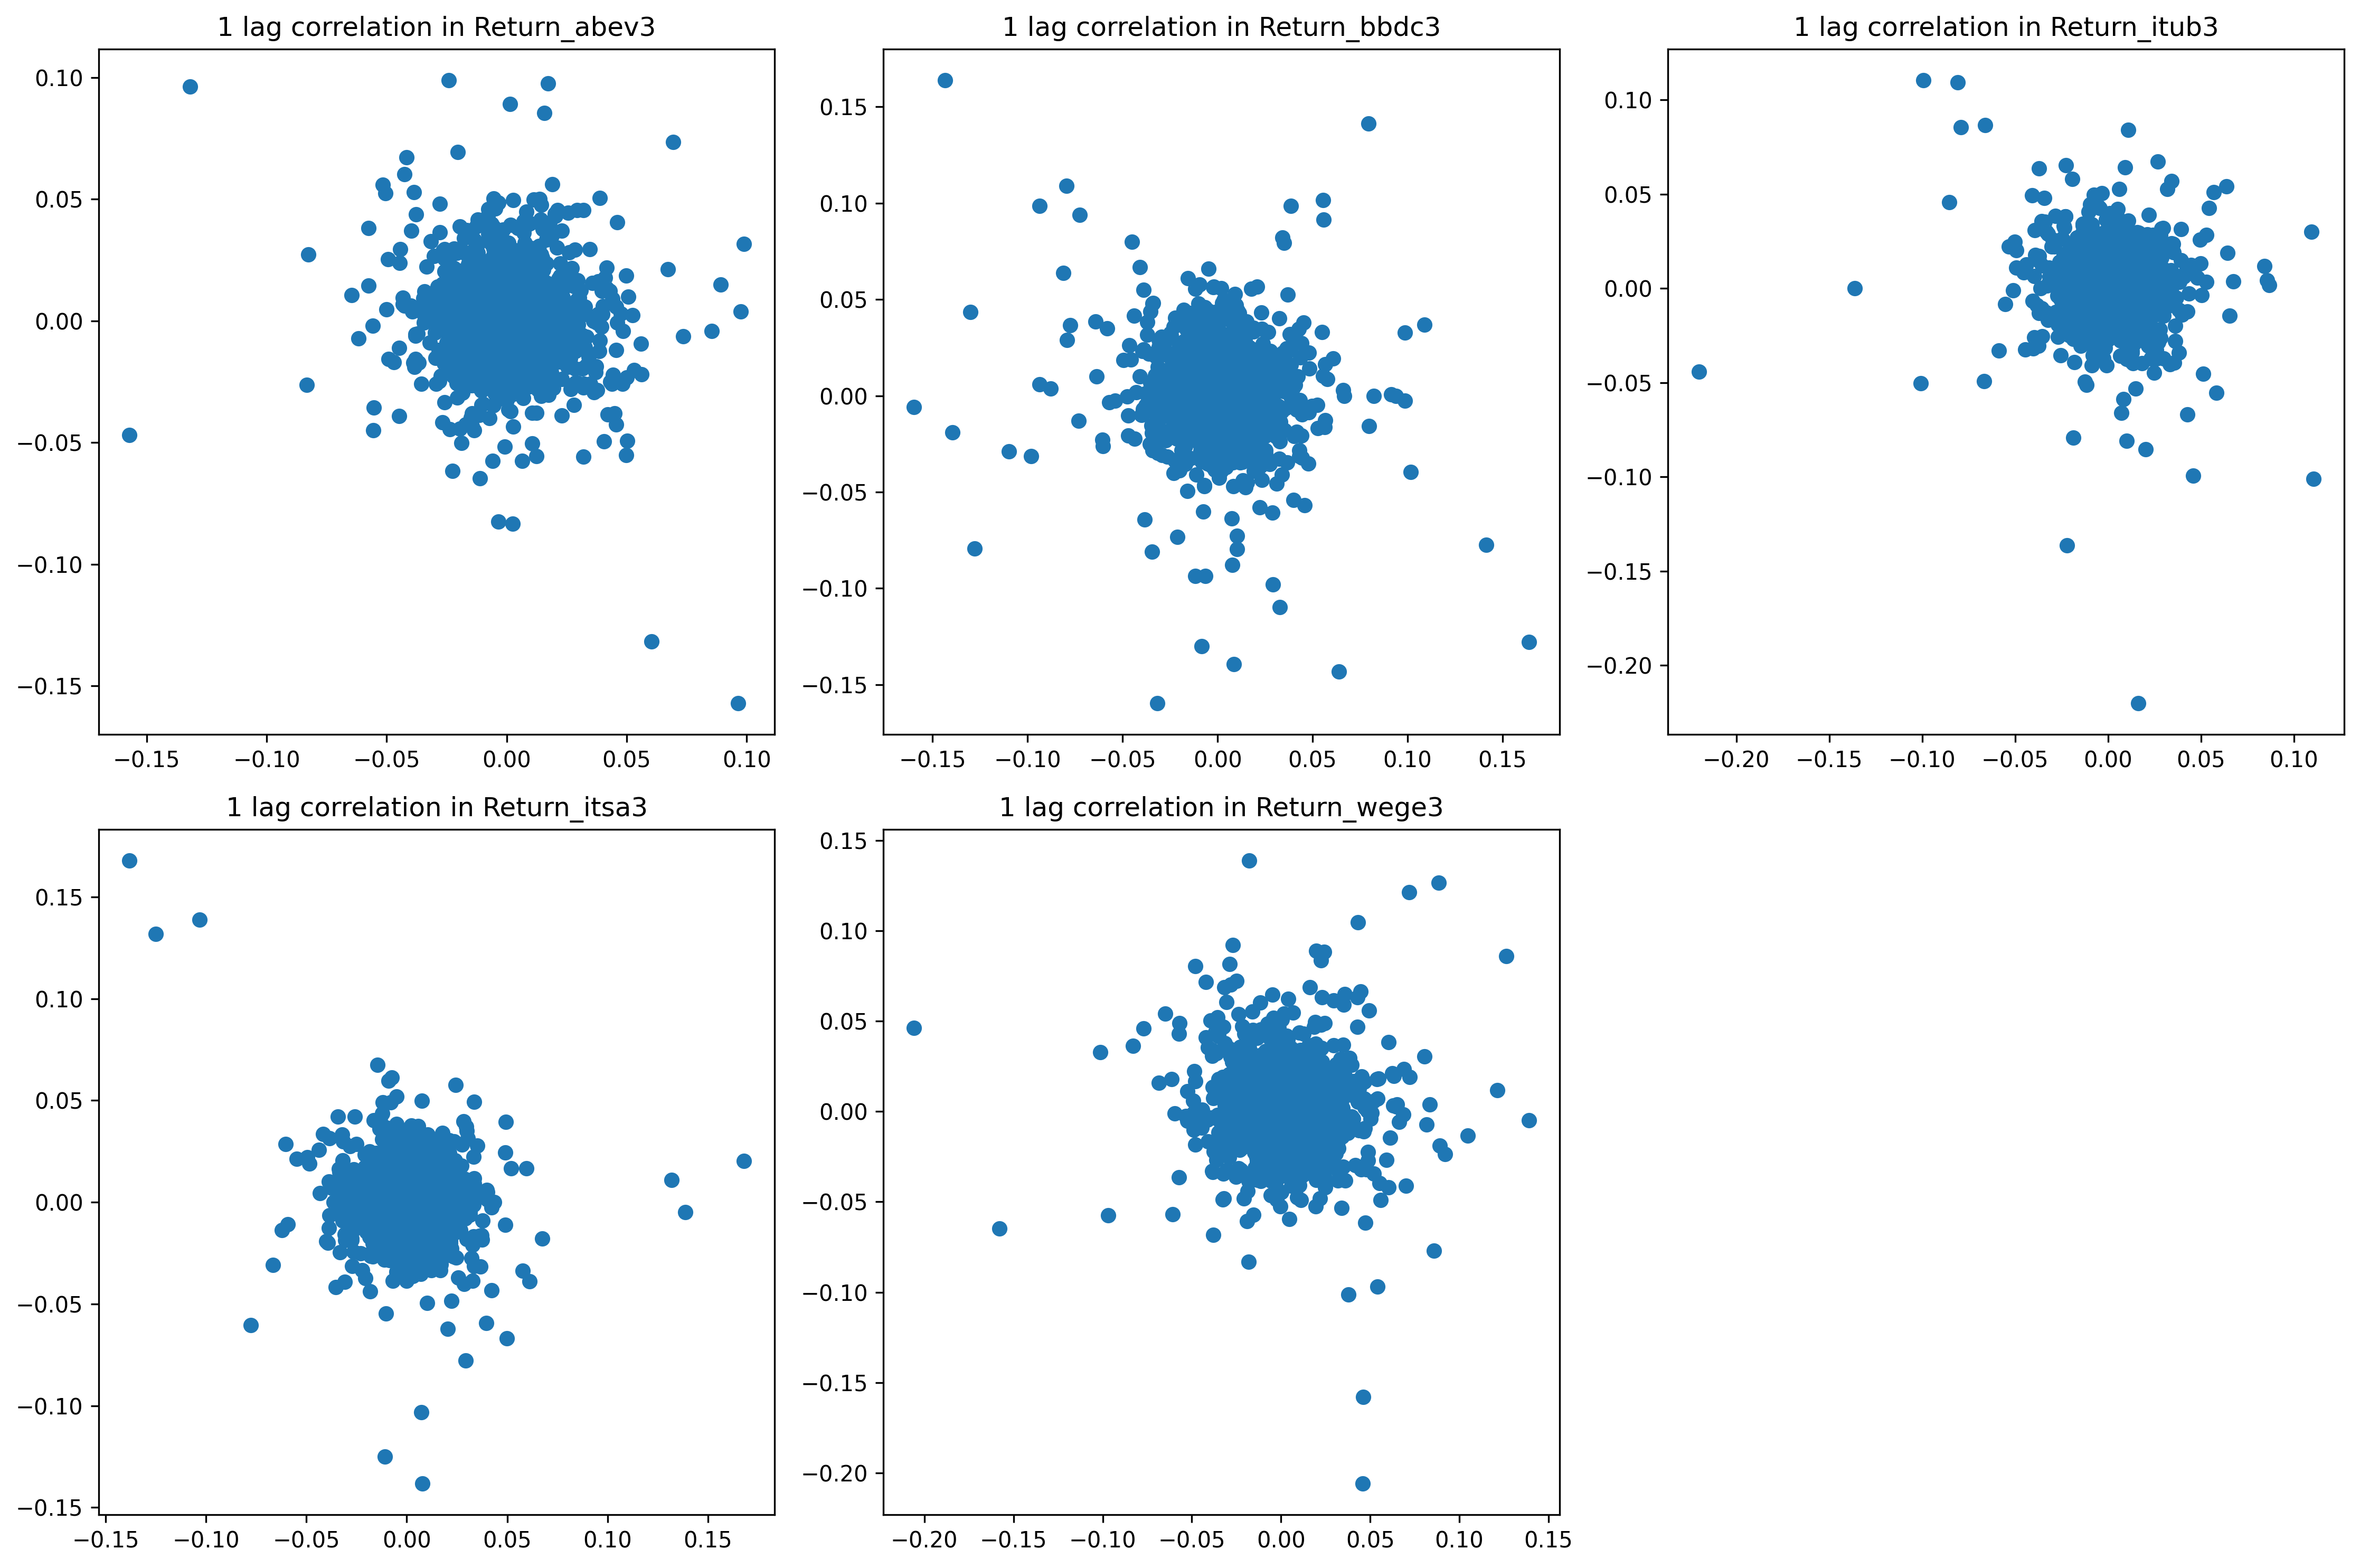

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

return_cols = [col for col in exploration_df.columns.tolist() if "Return" in col and "lag" not in col]
for i, col in enumerate(return_cols):
    new_df = pd.DataFrame()
    new_df[col] = exploration_df[col]
    new_df[f"{col}_shifted"] = exploration_df[col].shift(1)
    new_df.dropna(axis=0, inplace=True)
    print(f"corr between {col} and itself lagged: {pearsonr(new_df[col], new_df[f'{col}_shifted'])}")

    axes[i].scatter(new_df[col], new_df[f'{col}_shifted'])
    axes[i].set_title(f"1 lag correlation in {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Reforçando o argumento pró-retornos. As séries de preços tem alta correlação entre a série e a série atrasada, enquanto a série de retornos diferenciada não, mas a alta correlação é devido a tendência linear e não devido a poder preditivo real, por isso não é indicado usar a série de preços para prever movimentos. Isso não quer dizer que usar a série de retornos no lugar da série de preços garante poder preditivo real, mas evita cair no erro de ensinar o modelo a se basear no passo anterior para prever o próximo

In [43]:
stocks = ["abev3", "bbdc3", "itsa3", "itub3", "wege3"]

## Montando o dataframe

In [44]:
exploration_df.head()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3
Date,,,,,,,,,,
2018-10-11,13.67,15.00,23.51,6.83,8.88,-0.011569,0.006036,-0.011770,-0.005822,0.001127
2018-10-15,13.62,15.15,23.52,6.82,8.82,-0.003658,0.010000,0.000425,-0.001464,-0.006757
2018-10-16,14.00,15.79,24.32,7.01,9.04,0.027900,0.042244,0.034014,0.027859,0.024943
2018-10-17,13.71,15.80,24.49,6.98,8.99,-0.020714,0.000633,0.006990,-0.004280,-0.005531
2018-10-18,13.39,15.31,24.09,6.90,8.87,-0.023341,-0.031013,-0.016333,-0.011461,-0.013348


In [45]:
exploration_df = compute_targets(exploration_df, stocks)
exploration_df.head(15)

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3,abev3_y,bbdc3_y,itsa3_y,itub3_y,wege3_y
Date,,,,,,,,,,,,,,,
2018-10-11,13.67,15.00,23.51,6.83,8.88,-0.011569,0.006036,-0.011770,-0.005822,0.001127,False,True,False,True,False
2018-10-15,13.62,15.15,23.52,6.82,8.82,-0.003658,0.010000,0.000425,-0.001464,-0.006757,True,True,True,True,True
2018-10-16,14.00,15.79,24.32,7.01,9.04,0.027900,0.042244,0.034014,0.027859,0.024943,False,True,False,True,False
2018-10-17,13.71,15.80,24.49,6.98,8.99,-0.020714,0.000633,0.006990,-0.004280,-0.005531,False,False,False,False,False
2018-10-18,13.39,15.31,24.09,6.90,8.87,-0.023341,-0.031013,-0.016333,-0.011461,-0.013348,True,True,False,False,True
2018-10-19,13.56,15.34,23.87,6.87,8.97,0.012696,0.001960,-0.009132,-0.004348,0.011274,False,True,True,True,True
2018-10-22,13.53,15.52,24.09,6.98,8.99,-0.002212,0.011734,0.009217,0.016012,0.002230,False,True,False,False,True
2018-10-23,13.38,15.56,24.08,6.98,9.26,-0.011086,0.002577,-0.000415,0.000000,0.030033,False,False,False,False,True
2018-10-24,12.78,15.12,23.45,6.96,9.33,-0.044843,-0.028278,-0.026163,-0.002865,0.007559,False,True,True,True,False


In [46]:
exploration_df = compute_lags(exploration_df, exploration_df.columns.tolist())

exploration_df.head(15)

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3,...,Return_itub3_lag_3,Return_itub3_lag_4,Return_itsa3_lag_1,Return_itsa3_lag_2,Return_itsa3_lag_3,Return_itsa3_lag_4,Return_wege3_lag_1,Return_wege3_lag_2,Return_wege3_lag_3,Return_wege3_lag_4
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-11,13.67,15.00,23.51,6.83,8.88,-0.011569,0.006036,-0.011770,-0.005822,0.001127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-15,13.62,15.15,23.52,6.82,8.82,-0.003658,0.010000,0.000425,-0.001464,-0.006757,...,NaN,NaN,-0.005822,NaN,NaN,NaN,0.001127,NaN,NaN,NaN
2018-10-16,14.00,15.79,24.32,7.01,9.04,0.027900,0.042244,0.034014,0.027859,0.024943,...,NaN,NaN,-0.001464,-0.005822,NaN,NaN,-0.006757,0.001127,NaN,NaN
2018-10-17,13.71,15.80,24.49,6.98,8.99,-0.020714,0.000633,0.006990,-0.004280,-0.005531,...,-0.011770,NaN,0.027859,-0.001464,-0.005822,NaN,0.024943,-0.006757,0.001127,NaN
2018-10-18,13.39,15.31,24.09,6.90,8.87,-0.023341,-0.031013,-0.016333,-0.011461,-0.013348,...,0.000425,-0.011770,-0.004280,0.027859,-0.001464,-0.005822,-0.005531,0.024943,-0.006757,0.001127
2018-10-19,13.56,15.34,23.87,6.87,8.97,0.012696,0.001960,-0.009132,-0.004348,0.011274,...,0.034014,0.000425,-0.011461,-0.004280,0.027859,-0.001464,-0.013348,-0.005531,0.024943,-0.006757
2018-10-22,13.53,15.52,24.09,6.98,8.99,-0.002212,0.011734,0.009217,0.016012,0.002230,...,0.006990,0.034014,-0.004348,-0.011461,-0.004280,0.027859,0.011274,-0.013348,-0.005531,0.024943
2018-10-23,13.38,15.56,24.08,6.98,9.26,-0.011086,0.002577,-0.000415,0.000000,0.030033,...,-0.016333,0.006990,0.016012,-0.004348,-0.011461,-0.004280,0.002230,0.011274,-0.013348,-0.005531
2018-10-24,12.78,15.12,23.45,6.96,9.33,-0.044843,-0.028278,-0.026163,-0.002865,0.007559,...,-0.009132,-0.016333,0.000000,0.016012,-0.004348,-0.011461,0.030033,0.002230,0.011274,-0.013348


In [47]:
exploration_df[[col for col in exploration_df.columns.tolist() if "abev3" in col]].head()

,Price_abev3,Return_abev3,abev3_y,Return_abev3_lag_1,Return_abev3_lag_2,Return_abev3_lag_3,Return_abev3_lag_4
Date,,,,,,,
2018-10-11,13.67,-0.011569,False,NaN,NaN,NaN,NaN
2018-10-15,13.62,-0.003658,True,-0.011569,NaN,NaN,NaN
2018-10-16,14.00,0.027900,False,-0.003658,-0.011569,NaN,NaN
2018-10-17,13.71,-0.020714,False,0.027900,-0.003658,-0.011569,NaN
2018-10-18,13.39,-0.023341,True,-0.020714,0.027900,-0.003658,-0.011569


In [48]:
exploration_df[[col for col in exploration_df.columns.tolist() if "abev3" in col or "median" in col]].head(10)

,Price_abev3,Return_abev3,abev3_y,Return_abev3_lag_1,Return_abev3_lag_2,Return_abev3_lag_3,Return_abev3_lag_4
Date,,,,,,,
2018-10-11,13.67,-0.011569,False,NaN,NaN,NaN,NaN
2018-10-15,13.62,-0.003658,True,-0.011569,NaN,NaN,NaN
2018-10-16,14.00,0.027900,False,-0.003658,-0.011569,NaN,NaN
2018-10-17,13.71,-0.020714,False,0.027900,-0.003658,-0.011569,NaN
2018-10-18,13.39,-0.023341,True,-0.020714,0.027900,-0.003658,-0.011569
2018-10-19,13.56,0.012696,False,-0.023341,-0.020714,0.027900,-0.003658
2018-10-22,13.53,-0.002212,False,0.012696,-0.023341,-0.020714,0.027900
2018-10-23,13.38,-0.011086,False,-0.002212,0.012696,-0.023341,-0.020714
2018-10-24,12.78,-0.044843,False,-0.011086,-0.002212,0.012696,-0.023341


### Distribuição de classes

abev3_y
False    776
True     716
Name: count, dtype: int64
bbdc3_y
False    750
True     742
Name: count, dtype: int64
itsa3_y
False    756
True     736
Name: count, dtype: int64
itub3_y
False    762
True     730
Name: count, dtype: int64
wege3_y
True     761
False    731
Name: count, dtype: int64


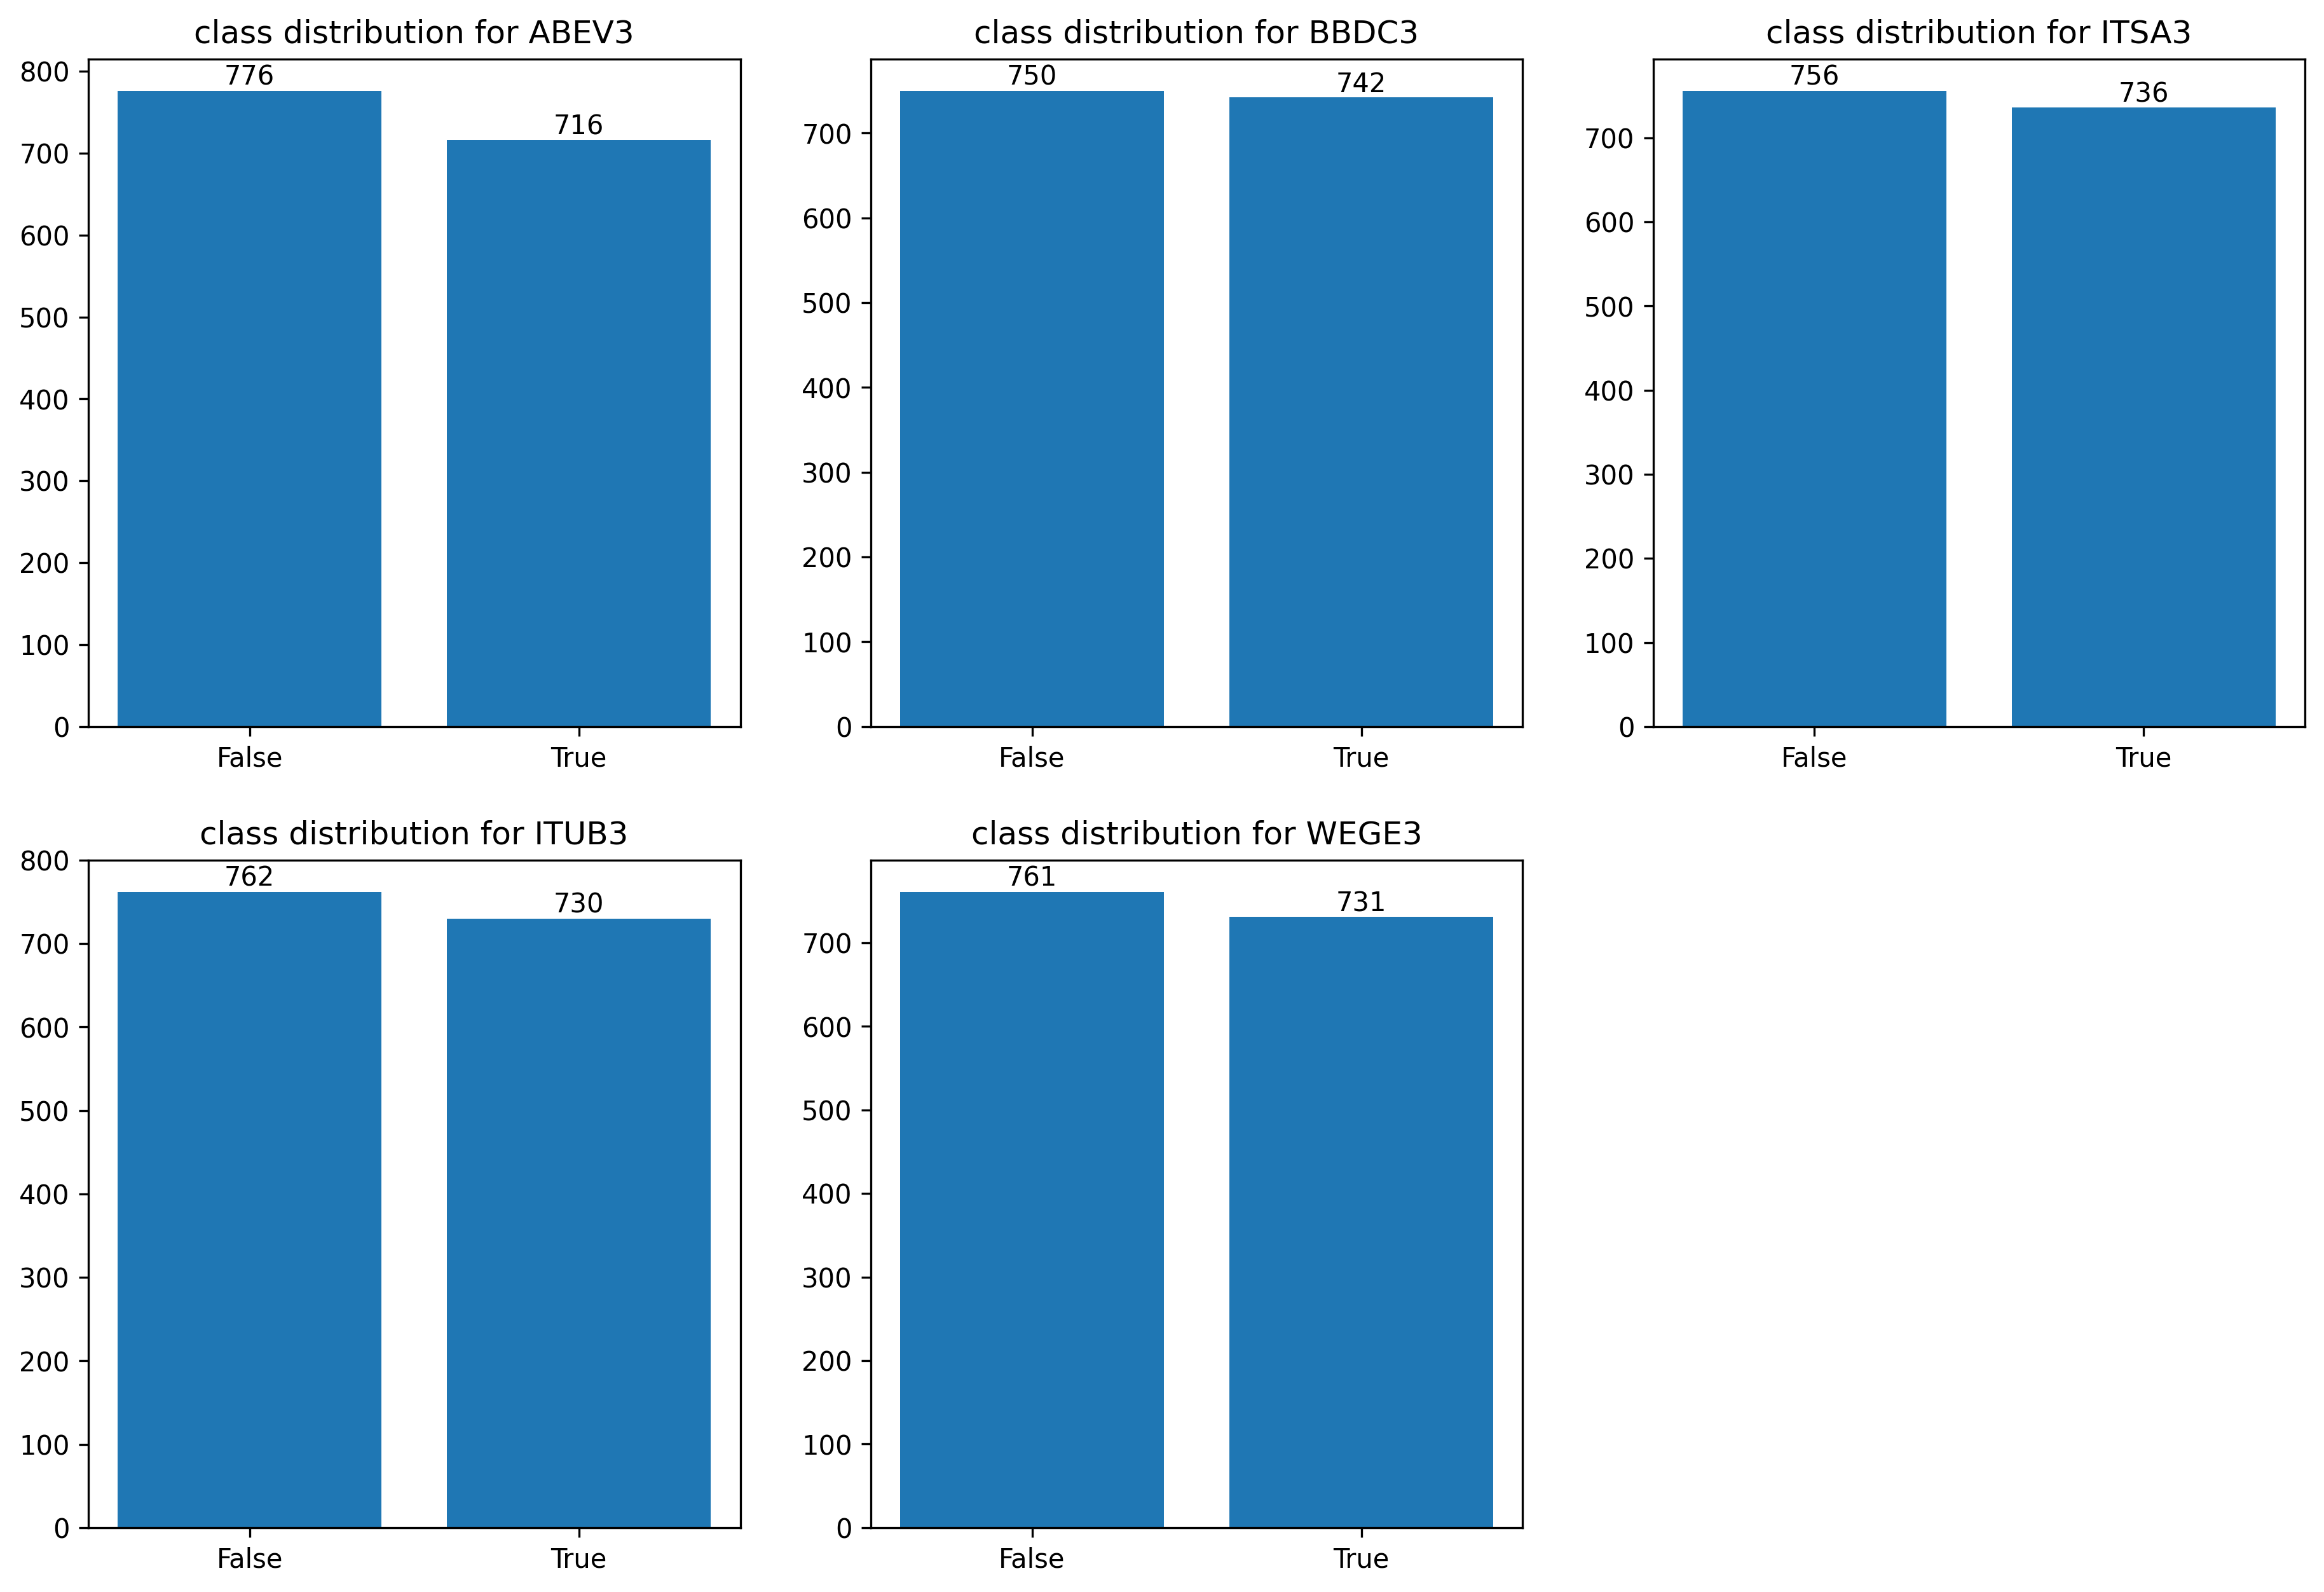

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(stocks):
    bars = axes[i].bar(["False", "True"], exploration_df[f"{col}_y"].value_counts())
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height}',
            ha='center', va='bottom'
        )
    print(exploration_df[f"{col}_y"].value_counts())
    axes[i].set_title(f"class distribution for {col.upper()}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

Observa-se que houveram mais ocorrências de retornos negativos do que positivos, mas apesar disso a média de retornos ainda é positiva, indicando que messmo na quantidade menor de retornos positivos, o valor deles superou o de retornos negativos. Além disso, as classes parecem bem balanceadas, com uma prevalência maior de ocorrências negativas

In [50]:
stocks_df.head()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3
Date,,,,,
2018-10-04,14.37,15.22,23.19,6.80,9.21
2018-10-05,14.20,14.78,23.44,6.80,9.21
2018-10-08,14.48,15.56,24.78,6.96,9.18
2018-10-09,14.06,15.58,24.54,6.99,8.82
2018-10-10,13.83,14.91,23.79,6.87,8.87


In [51]:
exploration_df.head()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3,...,Return_itub3_lag_3,Return_itub3_lag_4,Return_itsa3_lag_1,Return_itsa3_lag_2,Return_itsa3_lag_3,Return_itsa3_lag_4,Return_wege3_lag_1,Return_wege3_lag_2,Return_wege3_lag_3,Return_wege3_lag_4
Date,,,,,,,,,,,,,,,,,,,,,
2018-10-11,13.67,15.00,23.51,6.83,8.88,-0.011569,0.006036,-0.011770,-0.005822,0.001127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-10-15,13.62,15.15,23.52,6.82,8.82,-0.003658,0.010000,0.000425,-0.001464,-0.006757,...,NaN,NaN,-0.005822,NaN,NaN,NaN,0.001127,NaN,NaN,NaN
2018-10-16,14.00,15.79,24.32,7.01,9.04,0.027900,0.042244,0.034014,0.027859,0.024943,...,NaN,NaN,-0.001464,-0.005822,NaN,NaN,-0.006757,0.001127,NaN,NaN
2018-10-17,13.71,15.80,24.49,6.98,8.99,-0.020714,0.000633,0.006990,-0.004280,-0.005531,...,-0.011770,NaN,0.027859,-0.001464,-0.005822,NaN,0.024943,-0.006757,0.001127,NaN
2018-10-18,13.39,15.31,24.09,6.90,8.87,-0.023341,-0.031013,-0.016333,-0.011461,-0.013348,...,0.000425,-0.01177,-0.004280,0.027859,-0.001464,-0.005822,-0.005531,0.024943,-0.006757,0.001127


In [52]:
stocks_df.to_csv("data/stocks_df.csv")
exploration_df.to_csv("data/exploration_df.csv")

As transformações necessárias foram agregadas na função preprocess_data no módulo dataframe_helpers

O que mais vale a pena explorar?